## Introduction

You've never seen the word "wampimuk" before. But read this sentence:

"The wampimuk scurried across the forest floor and hid under a log."

You immediately know it's a small animal. You didn't look it up. You inferred its meaning from the words around it — scurried, forest floor, log. This is how humans understand language: not word by word in isolation, but through context, neighborhood, and relationship.

Computers have no such intuition. A neural network can recognize a cat in a photograph, beat a grandmaster at chess, and predict protein structures with atomic precision. But hand it the sentence "The bank was steep and muddy" and ask whether bank means a financial institution or a riverbank — and it has no idea. Not because it cannont compute, but because it lacks a of representation of what words `mean`. Computers are extraordinarily good at math. They can multiply matrices, minimize functions, and optimize billions of parameters — but they cannot read. To a computer, the word "king" is just a string of characters. 

Before we can do anything intelligent with language using a computer, we must answer a deceptively hard question:

> How do we turn words into numbers without losing meaning?

Word2Vec, introduced by Mikolov et al. at Google in 2013, was a landmark answer to these problems. In a few elegant ideas, it showed how to turn raw text into geometry — a vector space where meaning becomes distance, and relationships become directions. It operationalized the simple insight behind the wampimuk example: a word's meaning is defined by the company it keeps.

We are basically teaching a computer to read! This post tries to motivate the concepts of Word2Vec from the ground up.

_Assumed background: comfort with linear algebra (vectors, dot products, matrix multiplication), derivatives, Jacobians, gradient descent, and basic familiarity with neural networks._

## The Naive Approach: Representing Words as Numbers

### First attempt - Assign Arbitrary Integers

The most obvious way to turn words into numbers is to simply assign each word a unique integer. Given a vocabulary $V$ (of size |V|), we sort the words and map each to an index:

$\text{king} \to 0, \quad \text{man} \to 1, \quad \text{queen} \to 2, \quad \text{river} \to 3, \quad \text{woman} \to 4$

Formally:

$f: V \to \mathbb{Z}_{\geq 0}, \quad f(w_i) = i$ where $w_i$ is the i-th word in above numeric representation.

This is simple, compact, and unambiguous. Every word gets a unique number. So why doesn't this work?


#### Why Integers Fail

Integer representations carry implicit ordinal and magnitude information that is completely meaningless for words. The encoding above implies:

$\text{woman} > \text{queen} > \text{man} > \text{king}$

and that:

$\text{queen} - \text{king} = \text{river} - \text{man} = 2$

Neither of these relationships has any linguistic basis. Worse, any arithmetic we perform on these integers — addition, multiplication, distance — produces numbers that mean nothing. A model trained on integer word indices would be forced to learn that "queen" (index 2) is somehow "between" "man" (index 1) and "river" (index 3), which is nonsense.

We need a representation that carries no spurious relationships between words — a blank slate where every word starts as equally unrelated to every other word, and structure is only introduced by the data -- by training the model on the real data.

### Second attempt: One-Hot Encoding (OHE) — Integers as Indices

Consider this fix: instead of using the integer as the representation, use it as an index into a vector. We create a vector of length $|V|$ (one slot per word), place a $1$ at the position corresponding to the word's integer index, and fill everything else with $0$s.

Formally, for word $w_i$ with integer index $i$:

$$\mathbf{ohe}({w_i}) \in \{0, 1\}^{|V|}, \quad [\mathbf{ohe}({w_i})]_j = \begin{cases} 1 & \text{if } j = i \\ 0 & \text{otherwise} \end{cases}$$

For our 5-word vocabulary ($|V| = 5$):


$\begin{array}{c|ccccc} & \text{king}(0) & \text{man}(1) & \text{queen}(2) & \text{river}(3) & \text{woman}(4) \\ \hline  \text{king} & 1 & 0 & 0 & 0 & 0 \\ \text{man} & 0 & 1 & 0 & 0 & 0 \\ \text{queen} & 0 & 0 & 1 & 0 & 0 \\ \text{river} & 0 & 0 & 0 & 1 & 0 \\ \text{woman} & 0 & 0 & 0 & 0 & 1 \\ \end{array}$


The integer index tells us which position to set to $1$ — nothing more. The representation itself is now a vector, and all the problematic ordinal and magnitude relationships vanish. Each one-hot vector is a standard basis vector in $\mathbb{R}^{|V|}$. Any two distinct one-hot vectors are orthogonal, so their cosine similarity is exactly 0.

But, it's a fatal flaw!


Before we expose the problem with one-hot vectors, let's address one key ingredient: we need a way to measure how similar two words (actually their representations) are. The natural tool is cosine similarity — the cosine of the angle between two vectors:

$$\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{|\mathbf{a}| |\mathbf{b}|}$$

We use cosine similarity rather than raw Euclidean distance for a simple reason: we care about the direction a vector points, not how long it is. Two vectors pointing in the same direction should be considered identical in meaning regardless of their magnitudes. Cosine similarity measures directional alignment in the embedding space. Higher cosine often correlates with distributional relatedness, but not necessarily with synonymy or semantic opposition.

Now apply this to one-hot vectors. Since every one-hot vector has exactly one $1$ and the rest $0$s, the dot product between any two distinct words is zero:

$$\mathbf{ohe}({\text{king}}) \cdot \mathbf{ohe}({\text{queen}}) = 0 \implies \text{sim}(\mathbf{ohe}({\text{king}}), \mathbf{ohe}({\text{queen}})) = 0$$ 

$$\mathbf{ohe}({\text{king}}) \cdot \mathbf{ohe}({\text{river}}) = 0 \implies \text{sim}(\mathbf{ohe}({\text{king}}), \mathbf{ohe}({\text{river}})) = 0$$

Both similarities are identical — zero — even though king and queen are semantically close while king and river are not. The representation encodes zero semantic information and won't help to capture relationships between the words. Every word is equidistant from every other word in the cosine sense.

So with OHE, we've solved the spurious-relationship problem, but created a new one: the geometry of the space tells us nothing about the meaning of the words.

A side note: for a vocabulary of 50,000 words (typical for English), each OHE vector has 50,000 dimensions with exactly one non-zero entry — an extremely sparse and high-dimensional representation that is computationally wasteful.

## The Linguistic approach

Two naive attempts at representing words as numbers — arbitrary integers and one-hot encoding — both fell short. Let's turn to linguistics for a better path forward.


### The Distributional Hypothesis

The failure of one-hot encoding points us toward a deeper question: what is the meaning of a word? The linguist J.R. Firth (1957) offered a deceptively simple answer:

>You shall know a word by the company it keeps.

This is the distributional hypothesis: words that appear in similar contexts tend to have similar meanings. This isn't just a poetic observation — it's a falsifiable, empirically powerful claim that underlies virtually all of modern NLP.

The intuition is this: you don't need a dictionary to understand a new word. If you encounter the word "wampimuk" in the sentence "The wampimuk scurried across the forest floor and hid under a log," you immediately infer it's a small animal — not because you know the word, but because of the words surrounding it. `Context carries meaning`.

#### A Concrete Example: The Word "Bank"

Consider the word "bank" in two different contexts:

**Context A** — "The fisherman sat on the bank of the river, watching the water flow past."

Neighboring words: fisherman, river, water, flow, sat

**Context B** — "She deposited her savings at the bank before the weekend."

Neighboring words: deposited, savings, money, account, weekend

The word bank is identical in both sentences — same spelling, same pronunciation — yet its meaning is completely different. The neighborhood disambiguates it. Distributional context is a strong signal for meaning. `Dissimilar contexts → different meanings`.

Now consider two different words in similar contexts:
* "The doctor prescribed medication after the diagnosis."
* "The physician recommended rest and fluids."

Both doctor and physician appear near: prescribed / recommended, medication / rest, diagnosis / fluids, patient, hospital, treatment. Their neighborhoods are nearly identical — and indeed, they are nearly synonymous. `Similar usage patterns → similar meanings`.

This gives us a powerful and actionable idea:

>If we can encode a word's typical neighborhood into a dense, low-dimensional vector, then words with similar neighborhoods will end up close together in vector space. Semantic similarity becomes geometric proximity.

This is the core insight that Word2Vec operationalizes. The question is no longer "what does this word mean?" but rather "what does this word tend to appear next to?" — and that question can be answered from raw text, with no human annotation required.

To reiteraite, we want words appearing nearby to be closer with the hope that they are somehow related. For example if `king, emperor` occur nearby, we want them to be closer. Say, if again `princess, emperor` occur nearby, we want them to be closer as well.

If king and princess both occur in similar contexts to emperor, the training objective may place them nearer one another as a consequence of shared context statistics.

Now if `war` occurs not as often it may be farther from king/emperor/princess. Eventually positional relationship is used to create a (vector) spatial relationship.

Now, as a side effect we will have synonyms nearby (like `king` and `emperor` above).

As in OHE, if the vector space has the same dimension as the size of vocabulary, we may not be able to force them come to close, but if we have lower dimension, we may be able to. In a way this is similar to matrix decomposition into a lower rank. See appendices for more on this.

Word2Vec offers a powerful framework for learning word embeddings — but it is not without limitations. Some of these shortcomings, such as the inability to model asymmetric attention and context-dependent meaning, require a fundamentally different architecture to address. An appendix offers a brief look at how Transformers begin to overcome these limitations.

### The bridge from concepts to mathematics - Dense Embedding Vectors

Ok, now we have a conceptual action, how do we convert these concepts a mathematical formalism that helps an algorithm to find these vectors?

#### What Is an Embedding?

The distributional hypothesis tells us that meaning lives in context. To capture that, we need a representation that can encode degrees of similarity — not just presence or absence. The answer is a dense embedding vector.

An embedding maps each word $w$ to a point in a continuous vector space:

$$\mathbf{v}_w \in \mathbb{R}^d, \quad d \ll |V|$$

where $d$ is the embedding dimension (typically 50–300) and $|V|$ (sometimes size denoted just as V when it is clear from the context) is the vocabulary size (often 50,000+). Unlike one-hot vectors, these vectors are:

* Dense: most entries are non-zero real numbers
* Low-dimensional: $d = 300$ vs $|V| = 50{,}000$ — a 99.4% reduction in dimensionality
* Learned: the values are optimized from data, not hand-crafted
* Geometric Intuition: Similar Words Are Close

Once we have dense vectors, we can measure semantic similarity geometrically using cosine similarity — the cosine of the angle between two vectors:

$$\text{sim}(\mathbf{v}_a, \mathbf{v}_b) = \frac{\mathbf{v}_a \cdot \mathbf{v}_b}{|\mathbf{v}_a| |\mathbf{v}_b|} \in [-1, 1]$$

A value of $+1$ means the vectors point in the same direction (maximally similar); $0$ means orthogonal (unrelated); $-1$ means opposite directions (maximally dissimilar).

After training on a large corpus, the geometry of the embedding space reflects semantic structure:

$\text{sim}(\vec{\text{king}}, \vec{\text{queen}}) \approx 0.75$ — semantically close

$\text{sim}(\vec{\text{king}}, \vec{\text{river}}) \approx 0.02$ — semantically distant

Compare this to one-hot vectors, where both similarities are exactly $0$. The embedding space has learned to encode what one-hot encoding could not: the degree of semantic relatedness.

We want embeddings that are:

* dense rather than sparse,
* low-dimensional relative to the vocabulary size, and
* trained so that words with similar contexts receive similar vectors.

Importantly, this notion of similarity is distributional: it often overlaps with synonymy, but not always.

This model also acknowledges a couple of key limitations:

* ignores the order in which context words occur, it just limits to the neighbors in a given window.
* The similarity is here measured via the neighbors, not necessarily language synonyms like "car" and "automobile". This means we could find things such that "hot" and "cold" are similar because in many training data, they might have the same neighbors (datasets that deal with temperature, weather etc.,)


#### Vector Arithmetic: Geometry Encodes Relational Meaning

The most striking property of well-trained embeddings is that relational meaning is encoded as consistent geometric direction. The canonical example:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

Let's unpack what this means. The vector difference $\vec{\text{king}} - \vec{\text{man}}$ captures the concept of "royalty" — the direction in embedding space that separates a royal from a commoner. Adding that direction to $\vec{\text{woman}}$ lands near $\vec{\text{queen}}$. The analogy man : king :: woman : ? is solved by vector arithmetic.

This isn't a special case. The same structure holds across many relationships:

$$\vec{\text{Paris}} - \vec{\text{France}} + \vec{\text{Italy}} \approx \vec{\text{Rome}} \quad \text{(capital cities)}$$ $$\vec{\text{walked}} - \vec{\text{walk}} + \vec{\text{run}} \approx \vec{\text{ran}} \quad \text{(verb tense)}$$ $$\vec{\text{queen}} - \vec{\text{king}} + \vec{\text{actor}} \approx \vec{\text{actress}} \quad \text{(gender)}$$

( The result was a vector space where king and queen end up close together, where the equation $\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$ holds, and where a computer, for the first time, could begin to understand what words mean.)


The direction encoding "capital of" is consistent across different countries. The direction encoding "past tense of" is consistent across different verbs. Geometry in embedding space encodes relational meaning — and this structure is not hand-engineered. It emerges naturally from training on raw text.

 
#### The Central Question

This raises the question that the rest of this post answers:

>How do we actually learn these vectors from raw text?

We need an algorithm that, given an unlabeled corpus, produces embedding vectors where semantically similar words end up geometrically close. The answer is Word2Vec — and the key is to operationalize the distributional hypothesis as a prediction task that a neural network can be trained to solve.


We will answer this in five steps:
1.  create center–context training pairs,
2. map the center word to an embedding,
3. score every vocabulary word as a possible context,
4. convert scores to probabilities with softmax, and
5. optimize the loss by gradient descent.

#### The Word2Vec Mechanism: Skip-gram

Word2Vec (Mikolov et al., 2013) operationalizes the distributional hypothesis as a prediction task. It has a couple of recipes to do so: CBOW and Skip-gram. This post is about skipgram. See appendix for more information on CBOW.

The Skip-gram model asks:

>Given a center (target) word, can we predict the words that appear in its surrounding context window?

For the sentence "the quick brown fox jumps" with a window size of 2, the center word brown generates the following training pairs:

$$(\text{brown} \to \text{the}), \quad (\text{brown} \to \text{quick}), \quad (\text{brown} \to \text{fox}), \quad (\text{brown} \to \text{jumps})$$

We train a shallow neural network to perform this prediction. The crucial insight: we don't actually care about the predictions themselves — we care about the weight matrices learned during training. Those weight matrices are the embeddings.

Rest of the article talks about the Skipgram exclusively, starting with mathematical foundation.

A note on word Skip-gram: Instead of predicting next word, given a target (or center) word, predict other words around it in a given window, by **skip**ping (over the words) violating the sequential nature of linguistic text. The words are not considered in that order but only two at a time (center word and other word in the window). So, we lose the positional information. But it is still powerful in practice. Hence this is skipgram (instead of bigram/trigram/umpteenth gram).


## The Mathematical Foundation

### Dual Vector Representation

We use $w$ (for an arbitrary word) or $t$ (when a word is a center/focus/target word) or $c$ (when a word is context word). It could mean the numeric integer index into vocabulary list, or one hot embedding depending on context it will be clear.

Now, for a subtle crucial design choice: each word $w$ in the vocabulary has two separate learned vectors:

* $\mathbf{v}_w \in \mathbb{R}^d$ — the target (center) vector, used when $w$ is the center word
* $\mathbf{u}_w \in \mathbb{R}^d$ — the context vector, used when $w$ appears as a neighbor

These are stored in two separate embedding matrices:

$$W \in \mathbb{R}^{|V| \times d} \quad \text{(input / target matrix, row } i \text{ is } \mathbf{v}_{w_i}\text{)}$$

$$W' \in \mathbb{R}^{|V| \times |d|} \quad \text{(output / context matrix, row } j \text{ is } \mathbf{u}_{w_j}\text{)}$$

**Why two vectors?**

Separate vectors allow the model to learn asymmetric relationships: "bank" as a center word has a different distributional profile than "bank" as a context word. After training, we typically use $W$ (the target vectors) as the final embeddings, though averaging $W$ and $W'$ sometimes yields better results.

Because the same word plays two different roles in the model: one as a center word being used to make predictions, and one as a context word being predicted. Using separate parameter sets $\mathbf{v}_w$ and $\mathbf{u}_w$ makes the model more expressive and avoids forcing those two roles to share exactly the same geometry. Tying them is possible, but more restrictive.

We use $\theta$ to represent all of the 2 * d * |V| parameters from $W$ and $W'$ matrices above.

Here we are making forward references to the gradient descent process, it will be more clear once we go through it.

In summary:

In Skip-gram, every word plays two roles: sometimes it's the center word predicting context, sometimes it's a context word being predicted. These are fundamentally different jobs — like being a teacher vs. a student. If we force the same embedding to do both, we create conflicts because language relationships are directional and asymmetric (king→rules is different from obey→king). So Word2Vec uses two embedding matrices: one for the center role (W) and one for the context role (W'). This gives the model flexibility to capture asymmetric relationships without forcing them into a symmetric structure. After training, we keep W as the final embeddings and discard W' — it was just scaffolding to help W learn richer representations.

If you want, you can pause here and look at a couple of appendices to learn more about what happens if we use the same embedding vector for a word both when it is a center word and when it is a context word: (1) Positive Semi Definite Matrix (2) Shared vs. separate embeddings.


### From Raw Scores to Probability: The Softmax

Given a center word $t$ with target vector $\mathbf{v}_t$, and a context word $c$ with context vector $\mathbf{u}_c$, the raw compatibility score is the dot product (here dot product is take between the two vectors each drawn from two different embedding spaces described above):

$$s(t, c) = \mathbf{u}_c^T \mathbf{v}_t \in \mathbb{R}$$

This is a real number — positive if the vectors point in similar directions, negative if they diverge. This is not that helpful, we want higher values for related words and lower values for un-related ones. So, softmax comes to rescue. To convert these raw scores into a probability distribution over the entire vocabulary, we apply the softmax function. We take the dot product of target vector with each of the context vector (for all words in the vocabulary) for the denominator. Note that context vectors are taken from context embedding space:

$$\boxed{P(c \mid t) = \frac{\exp(\mathbf{u}_c^T \mathbf{v}_t)}{\displaystyle\sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)}}$$

Why does softmax arise naturally here? Several reasons make it the canonical choice:

* First note that softmax takes an arbitrary set of reals and converts into probabilities (that sum to 1) while preserving ordering but amplifying differences when numbers are spread out and compressing differences when scores are clustered.
* Softmax also preserves log-ratios: $log(\frac{p_i}{p_j}) = s_i-s_j$. It preserves the additive structure of scores in the multiplicative structure of probability ratios.
* Positivity: $\exp(\cdot) > 0$ always, so all probabilities are positive.
* Normalization: dividing by the sum ensures $\sum_{c \in V} P(c \mid t) = 1$ => a valid probability distribution.
* Amplification: the exponential sharpens differences — a word with a slightly higher dot product receives a disproportionately higher probability, creating confident predictions.
* Differentiability: softmax is smooth everywhere, enabling gradient-based optimization.
* For Skip-gram, softmax creates a "winner-take-most" effect, which helps the model make confident predictions when one context word is clearly more likely than others.

### How do we find the embeddings?

That's all fine, but how do we find the target and context embeddings? What is the math behind?

Use linear algebra. Let $d$ be the embedding dimension and $|V|$ be the vocabulary size. Assume the unknowns are $W$ (embeddings of vocabulary words as center words, $|V| \times d$) and $W'$ (embeddings of vocabulary words as context words, $|V| \times d$). We solve for $W$ and $W'$. Since there are more equations (when each training example is plugged in) than unknowns (the fixed count $|\Theta|$ of parameters $\Theta$), `we cannot solve the system exactly and must resort to iterative optimization via gradient descent`. An understanding of how it works is essential to comprehend the math in this article.

Gradient descent first runs the model forward to turn the input into a prediction and measure how wrong that prediction is with a loss function, then runs backward propagation to compute how each parameter contributed to that error and adjusts every parameter a small amount in the direction that reduces the loss. Gradient descent computes the prediction and loss in the forward pass, $\hat{y} = f_{\theta}(x), \qquad L = \ell(\hat{y}, y),$ then uses backpropagation to compute the gradient of the loss with respect to the parameters through the chain rule, $\nabla_{\theta} L,$ and updates the parameters by $\theta \leftarrow \theta - \eta \nabla_{\theta} L.$


Let the rows of $W$ be $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_{|V|} \in \mathbb{R}^d$ (the target embeddings, one per vocabulary word).


Let the rows of $W'$ be $\mathbf{u}_1, \mathbf{u}_2, \ldots, \mathbf{u}_{|V|} \in \mathbb{R}^d$ (the context embeddings, one per vocabulary word).


| Symbol | Meaning | Shape |
|---|---|---|
| t | index (into vocabulary) of the center word | scalar |
| w | the word itself in the vocab | text |
| c | index (into vocabulary) of a context word | scalar |
| $\mathbf{e}_t \in \mathcal{R}^{V}$ | one-hot vector for the center word | $V \times 1$ |
| $\mathbf{v}_t \in \mathcal{R}^{d}$ | embedding for center word, row t of W| $d \times 1$ |
| $\mathbf{u}_c \in \mathcal{R}^{d}$ | embedding for context word, row c of W' | $d \times 1$ |


For center word t with OHE $\mathbf{e}_t$, let the context words be $e_{c_1}, ... e_{c_{2m}}$.

Then, in matrix formulation:

$\mathbf{e}_t = \begin{bmatrix} 0 \\ \vdots \\ 1 \\ \vdots \\ 0 \end{bmatrix}$. Here element at row t is 1 and 0 elsewhere.


$W = \begin{bmatrix}v_{11} & v_{12} & \dots v_{1d}  \\ \dots \\ \dots \\ v_{v1} & v_{v2} & \dots v_{vd} \end{bmatrix}$ and $W' = \begin{bmatrix}u_{11} & u_{12} & \dots u_{1d}  \\ \dots \\ \dots \\ u_{v1} & u_{v2} & \dots u_{vd} \end{bmatrix}$.


$\mathbf{v}_t = W^T \mathbf{e}_t = \begin{bmatrix} v_{t1} \\ v_{t2} \\ \vdots \\ v_{td} \end{bmatrix} = \begin{bmatrix} W_{t,1} \\ W_{t,2} \\ \vdots \\ W_{t, d} \end{bmatrix}$. This is nothing but t-th row from W as a (column) vector.

$\mathbf{s} = W'  \mathbf{v}_t = \begin{bmatrix} s_{1} \\ \vdots \\ s_{2} \\ \vdots \\ s_{|V|} \end{bmatrix}$, are the raw similarity scores for each word in the (whole) vocabulary for center word $w_t$.


Each entry $s_i$ is a scalar ranging from $-\infty$ to $+\infty$.


$\mathbf{p} = softmax(\mathbf{s}) = \begin{bmatrix} p_{1} \\ p_{2} \\ \vdots \\ p_{V} \end{bmatrix}$, this is the model's belief about the similarity probability of each word in the entire vocabulary.

If we unpack above chain of functions, we get:

$p_i =  \frac{exp(\mathbf{u}_i^T \mathbf{v}_t)}{\sum_{x=1}^{|V|} exp(\mathbf{u}_x^T \mathbf{v}_t) } = P(i|t)$, probability of word i being a context word (i.e., is in context window) given center/target word t.


It's log is (useful later):

$$log(p_i) = \mathbf{u}_i^T \mathbf{v}_t - log({\sum_{x=1}^{|V|} exp(\mathbf{u}_x^T \mathbf{v}_t) })$$


Of the |V| numbers in $p$, we expect only 2m at the corresponding indices for c have high probability and rest 0 or low probability.


Skip-gram assumes the context words are conditionally independent given the center word, so the probability of the whole window is product of conditional probability of each context word. That means we can take product of the proabability of each context word $p_i$ for just context words c = 1 to 2m.


$$\mathcal{J}(\theta) = \prod_{i=1}^{i=2m} P(w_{c_i} | w_t ; \theta) = \prod_{i=1}^{i=2m} p_{c_i}$$.

This needs to be maximized (which will minimise the context words due to sum of the probabilities = 1).

This is same as minimizing the -ve log likelihood of $\mathcal{J}(\theta)$. Writing as:

$$\mathcal{L}(\theta) = -log \mathcal{J}(\theta) = -\sum_{i=1}^{i=2m} \log p_{c_i}$$

Above can be simplified to this:

Let $y_{c_i}$ be the one hot encoding of context word $c_i$. Then $\mathcal{L}(\theta) = -\sum_{i=1}^{i=2m} y_{c_i}^T log(\mathbf{p})$. 

Breaking this into per context word loss, $\mathcal{L_i}(\theta) = -y_{c_i}^T log(\mathbf{p})$ and hence $\mathcal{L}(\theta) = \sum_{i=1}^{i=2m} \mathcal{L_i}(\theta)$.


Expanding using $log(p_i)$ from above,

$$\mathcal{L}(\theta) = -\sum_{i=1}^{i=2m} \mathbf{u}_{c_i}^T \mathbf{v}_t + \sum_{i=1}^{i=2m} log({\sum_{x=1}^{|V|} exp(\mathbf{u}_x^T \mathbf{v}_t) }) = \sum_{i=1}^{i=2m} (-\mathbf{u}_{c_i}^T \mathbf{v}_t + log(Z(t)))$$

Here $Z(t) = \sum_{x=1}^{|V|} exp(\mathbf{u}_x^T \mathbf{v}_t)$


**Intuition for why this loss works**

Each term in the sum has two parts (for a given and hence constant $\mathbf{v}_{t}$):

The first term $\mathbf{u}_{c_i}^T \mathbf{v}_{t}$ is the raw score for the true context word. Minimizing $\mathcal{L}$ means maximizing this — pushing the target and true context vectors to be more aligned.

The second term $\log Z(t)$ is the log partition function. Minimizing $\mathcal{L}$ means minimizing this — pulling the target vector away from all context vectors.

The loss encodes a tug-of-war: attract true context words, repel all others. This is the distributional hypothesis expressed as an optimization objective.

### The Learning Dynamics

**We use denominator layout for gradient matrix or Jacobian in this article**

For a single (target, context) pair $(t, c)$, the loss is

$$\mathcal{L_{c}} = -\log P(c \mid t) = -\mathbf{u}_c^T \mathbf{v}_t + \log \sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)$$

Taking the gradient with respect to $\mathbf{v}_t$ and applying the chain rule:

$$\frac{\partial \mathcal{L_{c}}}{\partial \mathbf{v}_t} = -\mathbf{u}_c + \frac{\partial}{\partial \mathbf{v}_t} \log \sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)$$

The second term is a log-sum-exp derivative:

$$\frac{\partial}{\partial \mathbf{v}_t} \log \sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t) = \frac{\sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t) \cdot \mathbf{u}_w}{\sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)} = \sum_{w \in V} P(w \mid t) \cdot \mathbf{u}_w$$

Here, $$P(w \mid t) = \frac{\exp(\mathbf{u}_w^T \mathbf{v}_t)}{\sum_{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)}$$

Therefore:

$$\boxed{\frac{\partial \mathcal{L_{c}}}{\partial \mathbf{v}_t} = -\mathbf{u}_c + \sum_{w \in V} P(w \mid t) \cdot \mathbf{u}_w = -\mathbf{u}_c + \mathbb{E}[\mathbf{u}_w]}$$

${w \sim P(\cdot \mid t)}$

This is `elegant`: the gradient is the difference between the true context vector and the expected context vector under the current model. If the model already assigns high probability to the true context word, the expectation $\mathbb{E}[\mathbf{u}_w]$ is close to $\mathbf{u}_c$, the gradient is small, and the update is minor. If the model is wrong, the gradient is large and the update is aggressive.


Gradient with Respect to the Context Vectors $\mathbf{u}_w$:

For the true context word $c$:


First note that, $$\frac{\partial \mathcal{L_c}}{\partial \mathbf{u}_c} log \sum_{w \in V} exp(\mathbf{u}_w^T\mathbf{v}_t) = P(c \mid t) \cdot \mathbf{v}_t$$. So,

$$\frac{\partial \mathcal{L_{c}}}{\partial \mathbf{u}_c} = -\mathbf{v}_t + P(c \mid t) \cdot \mathbf{v}_t = -(1 - P(c \mid t)) \cdot \mathbf{v}_t$$

But, we need to update parameters in W' for the words who are not context words as well. So, for any other word $w \neq c$:

$$\frac{\partial \mathcal{L_{c}}}{\partial \mathbf{u}_w} = P(w \mid t) \cdot \mathbf{v}_t$$

These two cases unify cleanly with an indicator variable:

$$\boxed{\frac{\partial \mathcal{L_{c}}}{\partial \mathbf{u}_w} = \bigl(P(w \mid t) - \mathbf{1}[w = c]\bigr) \cdot \mathbf{v}_t}$$


When $w = c$: the factor $(P(c \mid t) - 1)$ is negative (since $P(c \mid t) \leq 1$), so the gradient descent update moves $\mathbf{u}_c$ toward $\mathbf{v}_t$.

When $w \neq c$: the factor $P(w \mid t)$ is positive, so the gradient descent update moves $\mathbf{u}_w$ away from $\mathbf{v}_t$.

**The Push-Pull Geometry of Learning**

The gradient updates have a beautiful geometric interpretation. At every training step, for a (target $t$, context $c$) pair:

* True context word $c$: its context vector $\mathbf{u}_c$ is pushed toward the target vector $\mathbf{v}_t$. The more the model underestimates $P(c \mid t)$, the stronger the push.
* All other words $w \neq c$: their context vectors $\mathbf{u}_w$ are pulled away from $\mathbf{v}_t$. Words the model incorrectly assigns high probability to are pulled away more strongly.

Over millions of training steps across the entire corpus, this push-pull dynamic organizes the embedding space so that words appearing in similar contexts end up geometrically close. The distributional hypothesis is not just a linguistic observation — it is now a geometric attractor built into the optimization dynamics.

The elegant symmetry: The center embedding learns by being pulled toward true context embeddings and pushed away from the model's expected context direction. The context embeddings learn by being pulled toward or pushed away from the center embedding, proportional to their prediction error. The two embedding spaces co-evolve, gradually aligning words that appear in similar contexts.

DO NOT TRY TO ENVISON context and target/center words being in the same vector space! That will give wrong understanding. A word has different embedding based on its current role as a center or target word or context word.

### A Tiny Example

Before going too deep into underlying math and embeddings are generated, let's walk through a small example.

Vocabulary (V = 5): [the, fox, quick, brown, jumps] Center word: "fox" (index 1). True context word: "quick" (index 2)

After the forward pass, the dot products between the center word embedding and each context embedding give us raw scores (logits):


| Word | Index | Raw Score (sᵢ) |
|---|---|---|
| the | 0 | 1.2 |
| fox | 1 | 0.5 |
| **quick** | **2** | **2.1** ← true context |
| brown | 3 | 0.8 |
| jumps | 4 | 0.3 |

**Step 1: Apply Softmax → Convert Scores to Probabilities**

First, exponentiate every score:

| Word | sᵢ | exp(sᵢ) |
|---|---|---|
| the | 1.2 | 3.320 |
| fox | 0.5 | 1.649 |
| **quick** | **2.1** | **8.166** |
| brown | 0.8 | 2.226 |
| jumps | 0.3 | 1.350 |
| | **Sum** | **16.711** |

Now divide each by the sum:

| Word | P(word \| "fox") |
|---|---|
| the | 3.320 / 16.711 = **0.199** |
| fox | 1.649 / 16.711 = **0.099** |
| **quick** | 8.166 / 16.711 = **0.489** |
| brown | 2.226 / 16.711 = **0.133** |
| jumps | 1.350 / 16.711 = **0.081** |
| | **Sum = 1.000** ✅ |


The model assigns 48.9% probability to "quick" being the context word.

**Step 2: Compute the Loss**

The true context word is "quick" with P = 0.489.

>Loss = -log(0.489) ≈ 0.716

The model was reasonably confident (48.9%), so the surprise is moderate.

What if the model were worse? Say P("quick") = 0.07:

>Loss = -log(0.07) ≈ 2.66 — much higher surprise, much larger loss.

What if the model were perfect? P("quick") = 1.0:

>Loss = -log(1.0) = 0 — no surprise, no loss.

**Step 3: Unpacking the Loss Formula**

Substituting the softmax definition into the loss:

>Loss = -log [ exp(s_true) / Σⱼ exp(sⱼ) ]

Using log rules (log(a/b) = log(a) - log(b)):

>Loss = -s_true + log[ Σⱼ exp(sⱼ) ]

With our numbers:
* -s_true = -2.1
* log(Σⱼ exp(sⱼ)) = log(16.711) = 2.816
 
>Loss = -2.1 + 2.816 = 0.716 ✅ (matches above)

The two terms have a beautiful interpretation:

| Term | Value | Meaning |
|---|---|---|
| **-s_true** | -2.1 | Reward for the true word's score — we want this *large* |
| **+log[Σ exp(sⱼ)]** | +2.816 | Penalty for giving mass to *all* words — we want this *small* |


The loss is minimized when the true word's score is high and all other scores are low.

**Step 4: The Error Signal — What Gets Corrected?**

After computing the loss, backpropagation computes the gradient with respect to each score sᵢ:

>∂Loss/∂sᵢ = P(wordᵢ | center) − 1{wordᵢ is true context}

With our numbers:


| Word | P(wordᵢ) | True? | Gradient |
|---|---|---|---|
| the | 0.199 | No | 0.199 − 0 = **+0.199** → push score *down* |
| fox | 0.099 | No | 0.099 − 0 = **+0.099** → push score *down* |
| **quick** | **0.489** | **Yes** | 0.489 − 1 = **−0.511** → push score *up* |
| brown | 0.133 | No | 0.133 − 0 = **+0.133** → push score *down* |
| jumps | 0.081 | No | 0.081 − 0 = **+0.081** → push score *down* |


The gradient is simply "predicted probability minus ground truth". The model is told exactly how wrong it was for every word, and the correction is proportional to the mistake.

**Step 5: Multiple Context Words (Full Window)**

In practice, "fox" might have context words ["quick", "brown"] (window size = 1 on each side). The total loss is just the sum of individual losses:

> Total Loss = Loss("quick" | "fox") + Loss("brown" | "fox") = 0.716 + (-log(0.133)) = 0.716 + 2.017 = 2.733

Each context word contributes its own surprise. The gradients from all context words accumulate and jointly update the embeddings.

**The Full Picture**

```
Center word "fox"
      ↓
  Embedding lookup → vector e_fox
      ↓
  Dot product with all 5 context embeddings → scores [1.2, 0.5, 2.1, 0.8, 0.3]
      ↓
  Softmax → probabilities [0.199, 0.099, 0.489, 0.133, 0.081]
      ↓
  True context = "quick" (index 2), P = 0.489
      ↓
  Loss = -log(0.489) = 0.716
      ↓
  Gradient for each word = P(word) - truth = [+0.199, +0.099, -0.511, +0.133, +0.081]
      ↓
  Update embeddings: pull "quick" closer to "fox", push others away
```

### Full gradient derivation

**Let's use the denominator layout (gradient layout) for Jacobian in what follows:**
* The key distinction is the chain-rule multiplication swaps the factors.
* One nice side effect is that it shows the gradient flow and math notation is simpler (avoiding a lot of transposes).
* This also follows pytorch convention so will be a straight-forward translation to code.


| Symbol | Meaning | Shape |
|---|---|---|
| W | Center/target embedding matrix | V×d |
| $\mathbf{v}_t$ | Center word embedding (row t of W) | d×1 |
| W' | Context embedding matrix | V×d |
| 2m | Context window size, m words to left and m words to the right of center word| scalar |
| $c_i$ | i-th context word using the -m to m index range | scalar |
| $\mathbf{u}_j$ | Context embedding for word j (row j of W') | d×1 |
| $\mathbf{s}$ | Score vector: $\mathbf{s}_j =  \mathbf{u}^T_j \mathbf{v}_t$ | V×1 |
| $\mathbf{p}$ | Softmax output: $p_j = exp(\mathbf{s}_j)/\sum_{k} exp(\mathbf{s}_k)$ | V×1 |
| $\mathbf{y}_{c_i}$ | One-hot vector for context word $c_i$. Note that we index 1 to 2m context words for <br>a window of -m to +m around the center/target word.<br> index 0 is not included in the context words as it is a center word. The $c_i$ corresponds to integer in vocabulary. <br>See below for an example.| V×1 |
| $\mathcal{L}$ | Total loss over 2m context words | scalar |
| V | vocabulary or the size of vocabulary, meaning clear from context ! :) we are using `context` here| scalar |
| $\odot$ | element-wise multipication | same as inputs |
| @ | matrix multiplication of $m \times n$ with $n \times k$. Sometimes omitted for example $W@\mathbf{s} = W\mathbf{s}$ | $m \times k$ |
| * | scalar multiplication | scalar |
| $d\mathbf{x}$, or $dW$ | shortcut to $d\mathbf{x} = \frac{\partial \mathcal{L}}{\partial \mathbf{x}}$ or $dW = \frac{\partial \mathcal{L}}{\partial W}$ | vector or matrix |

A note on context word indexing. Say center word is 38 (integer in the vocab, or the 38-th position in OHE is 1 and remaining are 0). Say m=2, let the word sequence be: 2, 45, 38, 57, 7. Here $c_i$ is 2, 45, 57, 7 for i=1, 2, 3, 4 respectively.




Notice the dependency order from above matrix equations: W' -> s -> p -> $\mathcal{L}$.


Loss due to a single context word : $\mathcal{L_c}(\theta) = -\mathbf{y}_{c}^T log(\mathbf{p}) = -\sum_{j=1}^{j=V} (y_c)_{j} log(p_j)$.

Looks complicated, but given $\mathbf{y}_{c}$ ohe, only one element (at c) is 1 rest are zero. So, all above doing is plucking c-th element of $log(\mathbf{p})$ and negating.


It's derivative w.r.t a single probability component: $\frac{\partial \mathcal{L_c}}{\partial {p_j}} = -\frac{(y_c)_{j}}{p_j}$.

So, $L_c$'s Jacobian: $\frac{\partial \mathcal{L_c}}{\partial \mathbf{p}} = \begin{bmatrix} -\frac{(y_c)_{1}}{p_1} \\ -\frac{(y_c)_{2}}{p_2} \\ \vdots \\ -\frac{(y_c)_{V}}{p_V} \end{bmatrix}$ (shape: $V \times 1$).

It can be written succicently like this:

Let $\frac{1}{\mathbf{p}} = \begin{bmatrix} \frac{1}{p_1} \\ \frac{1}{p_2} \\ \vdots \\ \frac{1}{p_V} \end{bmatrix}$ (shape: V x 1)

Then $\frac{\partial \mathcal{L_c}}{\partial \mathbf{p}} = -y_{c} \odot \frac{1}{\mathbf{p}}$



Total loss: $\mathcal{L}(\theta) = -\sum_{c=1}^{c=2m} y_{c} log(\mathbf{p})$

$d\mathbf{p} = \frac{\partial \mathcal{L}}{\partial \mathbf{p}} = -\sum_{c=1}^{c=2m} y_{c} \odot \frac{1}{\mathbf{p}} = - (\sum_{c=1}^{c=2m} y_{c}) \odot \frac{1}{\mathbf{p}} = -\frac{1}{\mathbf{p}} \odot (\sum_{c=1}^{c=2m} y_{c})$.

Let's set $\mathbf{c\_count} = (\sum_{c=1}^{c=2m} y_{c})$

Then $\frac{\partial \mathcal{L}}{\partial \mathbf{p}} = -\frac{1}{\mathbf{p}} \odot \mathbf{c\_count}$


$\mathbf{p} = softmax(\mathbf{s})$

Jacobian of $\mathbf{s}$ w.r.t $\mathbf{p}$ (denominator layout):

$\frac{\partial \mathbf{p}}{\partial \mathbf{s}} = \begin{bmatrix} p_1(1-p_1) && -p_1p_2 && \dots && -p_1p_{|V|} \\  -p_2p_1 && p_2(1-p_2) && \dots && -p_2p_{|V|} \\ \vdots \\ -p_Vp_1 && -p_Vp_2 && \dots && p_V*(1-p_V) \end{bmatrix} = diag(\mathbf{p}) - \mathbf{p}\mathbf{p}^T$


$d\mathbf{s} = \frac{\partial \mathcal{L}}{\partial \mathbf{s}} =  \frac{\partial \mathbf{p}}{\partial \mathbf{s}} @ \frac{\partial \mathcal{L}}{\partial \mathbf{p}} = (diag(\mathbf{p}) - \mathbf{p}\mathbf{p}^T) @ (-\frac{1}{\mathbf{p}} \odot \mathbf{c\_count})$


When a  diagonal matrix $diag(\mathbf{p})$ ($V \times V$) multiplied by a vector $v$ ($V \times 1$), the result is a vector of size ($V \times 1$) where each element is $p_j*v_j$. So the first term becomes:

$diag(\mathbf{p}) @ (-\frac{1}{\mathbf{p}} \odot \mathbf{c\_count}) = \begin{bmatrix} -p_1*\frac{1}{p_1}*{c\_count}_1 \\ \vdots \\ \end{bmatrix} = -\mathbf{c\_count}$

Now let's simplify the second term:

$\begin{bmatrix} \frac{1}{p_1} \\ \frac{1}{p_2} \\ \vdots \\ \frac{1}{p_V} \end{bmatrix} \odot \mathbf{c\_count} = \begin{bmatrix} \frac{c\_count_1}{p_1} \\ \frac{c\_count_2}{p_2} \\ \vdots \\ \frac{c\_count_V}{p_V} \end{bmatrix}$

$\begin{bmatrix} p_{1} && \dots && p_{2} && \dots && p_{V} \end{bmatrix} @ \begin{bmatrix} \frac{c\_count_1}{p_1} \\ \frac{c\_count_2}{p_2} \\ \vdots \\ \frac{c\_count_V}{p_V} \end{bmatrix} = \sum_{i=1}^{V} c\_count_i$ = count of context words = 2m.

$(\mathbf{p}\mathbf{p}^T) @ (\frac{1}{\mathbf{p}} \odot \mathbf{c\_count}) = 2m \mathbf{p}$

$d\mathbf{s} = 2m \mathbf{p} -\mathbf{c\_count} = \mathbf{E}$ (say). This is of shape V x 1. Let's call this  accumulated error vector.

This is a beautiful result: the gradient of the total loss w.r.t. the score vector is simply the accumulated prediction error.



Let's look at the derivative of total loss w.r.t. a single element of W', say $(W')_{i, j}$

$\mathbf{s} = W' @ \mathbf{v}_t$. So, $s_i = \sum_{j=1}^{d} W'_{i, j}*(\mathbf{v}_t)_j$ =>  $\frac{\partial s_i}{\partial W'_{i, j}} = (\mathbf{v}_t)_j$.

And $\frac{\partial \mathcal{L}}{\partial W'_{i, j}} = \frac{\partial \mathcal{L}}{\partial s_i} * \frac{\partial s_i}{\partial W'_{i, j}} = \mathbf{E}_i * (\mathbf{v}_t)_j$.


$dW' = \begin{bmatrix} \mathbf{E}_1 * (\mathbf{v}_t)_1 && \mathbf{E}_1 * (\mathbf{v}_t)_2 \dots \\ \vdots \end{bmatrix} = \mathbf{E} @ \mathbf{v}_t^T = \mathbf{E} \otimes_{outer} \mathbf{v}_t$

Or succintly, $dW' = \frac{\partial \mathcal{L}}{\partial \mathbf{s}} @ \mathbf{v_t}^T = \mathbf{E} @ \mathbf{v}^T_t = \mathbf{E} \otimes_{outer} \mathbf{v}_t$



**Now let's calculate dW**

$\mathbf{s} = W' @ \mathbf{v}_t$

Hence, $\frac{\partial \mathbf{s}}{\partial \mathbf{v}_t} = W'^T$ (see appendix for a proof).

$(\mathbf{v}_t)_j  =  W_{t, j}$. (See the matrix definitions above)

$\frac{\partial (\mathbf{v}_t)_j}{\partial W_{i, k}} = 1$ when i=t, j=k. Else 0. 

So, $\frac{\partial \mathbf{v}_t}{\partial W_{i, k}} = \begin{bmatrix} \frac{\partial (\mathbf{v}_t)_1}{\partial W_{i, k}}  && \dots && \frac{\partial (\mathbf{v}_t)_d}{\partial W_{i, k}}  \end{bmatrix} = \begin{bmatrix} 0 && \dots   \end{bmatrix}$ (due to denominator layout). It has all zeros except when i=t it is 1 at column k. This is of shape $1 \times d$.

So, derivatives of most of the elements of W are zero except for one row, t. So, gradient update is sparse.



$dW_{t,k} = \frac{\partial \mathcal{L}}{\partial W_{t,k}} = \frac{\partial \mathbf{v}_t}{\partial W_{t, k}} @ \frac{\partial \mathbf{s}}{\partial \mathbf{v}_t} @ \frac{\partial L}{\partial \mathbf{s}} = (W'^T @ \mathbf{E})_k = \sum_{i=1}^{V} u_{ik} * E_i$

Assembling for all k = 1 to d:

$dW_t = \begin{bmatrix}\sum_{i=1}^{V} u_{i1} * E_i && \sum_{i=1}^{V} u_{i2} * E_i && \dots && \sum_{i=1}^{V} u_{id} * E_i \end{bmatrix} = \sum_{i=1}^{V}  \begin{bmatrix} u_{i1} * E_i && u_{i2} * E_i && \dots && u_{id} * E_i \end{bmatrix} = (\sum_{i=1}^{V} E_i * \begin{bmatrix} u_{i1} \\ u_{i2} \\ \vdots \\ u_{id}  \end{bmatrix})^T = \mathbf{E}^T @ W'$

This is a weighted sum of all context embeddings, where the weight for each context embedding $u_i$ is the prediction error $E_i$.



Notice the asymmetry in the gradient updates to W when compared to that of W': except for row t, all other derivatives of elements of W are 0:

Hence $dW = \begin{bmatrix} 0 && \dots && 0 && \dots && d-times \\ \vdots \\ dW_{t, 1} && dW_{t, 2} \dots && dW_{t, d} \\ \vdots \end{bmatrix}$

There's a beautiful asymmetry in these updates:

* W' is dense: every single row of W' gets updated on every training step (because every word gets a non-zero error eⱼ = P(j|t) > 0 even if it's not the true context word)
* W is sparse: only the one row corresponding to the current center word gets updated; all other rows of W are untouched

This sparsity in W updates is why Skip-gram can be trained efficiently with sparse gradient updates — a key practical advantage.



**Summary of the equations**

|Step|Operation|Formula|Shape|
|-- | -- | -- | --|
|1. Selection|Input lookup|$\mathbf{v}_t = W^T\mathbf{e}_t$| ($d \times V$) @ ($V \times 1$)   -> ($d \times 1$)|
|2. Scores| Matrix multiply | $\mathbf{s} = W'  \mathbf{v}_t$ | ($V  \times d$) @ ($d \times 1$) -> ($V \times 1$)|
|3. Softmax| Probabilities | $\mathbf{p} = softmax(\mathbf{s})$ | element-wise operation -> ($V \times 1$)|
|4. Loss| Cross-entropy | $\mathcal{L}(\theta) = -\sum_{c=1}^{c=2m} y_{c} log(\mathbf{p})$ | scalar|
|5. Error| Score gradient | $\mathbf{E} = d\mathbf{s} = 2m \mathbf{p} -\mathbf{c\_count}$ | (pred-onehot)  -> ($V \times 1$)|
|6. Output grad| $W'$ update (Dense)| $dW' = \mathbf{E} \otimes_{outer} \mathbf{v}_t$ | ($V \times d$) $\otimes_{outer}$ ($V \times 1$) -> ($V \times d$)|
|7. W' adjust | subtract | $W' = W' - \text{lr} * dW'$ |   ($V \times d$) |
|8. Hidden grad| Vector update | $\frac{\partial \mathbf{s}}{\partial \mathbf{v}_t} = W'^T$|  transpose -> ($d \times V$)|
|9. Input grad| $W$ t-th row update (Sparse)| $dW_t = \mathbf{E}^T @ W'$  | ($1 \times V$) @ ($V \times d$) -> ($1 \times d$)|
|10. W adjust | subtract just one row | $W_t = W_t-\text{lr} * dW_t$ |   ($1 \times d$) |



## Batching

In practice, calculating gradients for a single center word at a time is inefficient. Instead, we process a mini-batch of center-context word pairs simultaneously using vectorized matrix operations.

1. The Forward Pass

Instead of a single one-hot vector, we use a batch matrix X of shape ($N \times V$), where each row is the one-hot encoding (OHE) of a center word.

Hidden Layer (H): We extract the center word embeddings
$$H = XW (N \times V) @ (V \times d) -> (N \times d)$$

Output Scores (S): Using the transposed output weight matrix W'' (where W'' = $W'^T$):
$$S= HW''      (N \times d) @ (d \times V) -> (N \times V)$$ 

Predictions ($\{hat}Y$): We apply the softmax function row-wise to convert scores into probabilities.
$$\{hat}Y = softmax(S, dim=1) (N \times V)$$

2. The Target Matrix
Let Y ($N \times V$) be the matrix where each row is the OHE of the target context word corresponding to the center word in the same row of X.

3. Loss Calculation
The goal is to calculate the negative log-likelihood for the correct context words across the batch. Mathematically, we need to "pluck" the elements of $\{hat}Y$
 where the corresponding element in Y is 1.

There are two ways

**Method A**: Hadamard Product

We can isolate the correct log-probabilities using the Hadamard (element-wise) product. To sum all elements of the resulting matrix using only matrix operations, we pre- and post-multiply by an all-ones vector $\mathbf{1}$ (where $\mathbf{1}_k$ is a column vector of ones of size k):

$$J = -\frac{1}{N} \mathbf{1}^T_N\Bigg(Y \otimes_{hadamard} log(\hat{Y})\Bigg)\mathbf{1}_V$$

**Method B**: Trace Operator

Alternatively, we can use the Trace operator. The product $\hat{Y}Y^T$ (or $Y^Tlog(\hat{Y})$)results in a matrix where the diagonal contains the specific log-probabilities for our N samples.


$$J = -\frac{1}{N} tr(Y(log(\hat{Y}))^T)$$

(Note: $tr(AB^T)$ is the standard inner product for matrices, effectively summing the values where Y masks $log(\hat{Y})$


4. Gradient

By treating the average loss J as our objective function, we calculate its rate of change with respect to every parameter in W and W''. Since each item in the batch is a separate pass through the network, the resulting gradient is the average of the individual gradients for those N samples, providing a more stable update signal than a single-word pass.



The power of the Cross-Entropy loss combined with Softmax is that the derivative simplifies significantly. The error signal E represents the difference between our predictions and the ground truth.

The Error Matrix (E):

$$E = \frac{1}{N}(\hat{Y}-Y) (N \times V)$$


Each row i in E is the "error vector" for sample i, showing how far our probabilities $\bar{y}_i$ were from the one-hot target $y_i$.

Updating the Output Matrix (W''):

We calculate the gradient for the output embeddings by multiplying the hidden states H by the error E.

$$dW'' = E(W'')^T (N \times V) @ (V \times d) -> (N \times d)$$

Updating the Input Matrix (W):

First, we find the gradient for the hidden layer H, then map it back to the specific center words in W using the selection matrix X.

$$dH = E@(W'')^T (N \times V) @ (V \times d) -> (N \times d)$$ 

$$dW = X^T@dH (V \times N) @ (N \times d) -> (V \times d)$$ 

Finally, we update the parameters using the learning rate $\eta$:

$$W <- W - \eta dW$$
$$W'' <- W'' - \eta dW''$$

This completes the cycle: the Forward Pass generates a prediction, the Loss Function measures the error, and the Backward Pass (Gradients) tells us exactly how to nudge our word vectors to improve the next prediction.



|Step|Operation|Formula|Dimensions|
|-- | -- | -- | --|
|1. Selection|Input lookup|$H = X@W_1$| ($N \times V$) @ ($V \times d$) -> ($N \times d$)|
|2. Scores| Matrix multiply | $U = H @W_2$ | ($N  \times d$) @ ($d \times V$) -> ($N \times V$)|
|3. Softmax| Probabilities | $\hat{Y} = softmax(U, dim=1)$ | row-wise operation -> ($N \times V$)|
|4. Loss| Cross-entropy | $J = \frac{1}{N} \sum \limits_{i=1}^{N} \sum \limits_{j=1}^{V} Y_{i,j} log\Bigg(\frac{exp(U_{i,j})}{\sum \limits_{k=1}^{V}exp(U_{i,k})}\Bigg) =-\frac{1}{N} \sum \limits_{i=1}^{N} log(\hat{Y}_{i, \text{target}_i})$ | scalar -> ($1 \times 1$)|
|5. Error| Score gradient | $dU = E = \frac{1}{N} (\hat{Y}-Y)$ | (pred-onehot)  -> ($N \times V$)|
|6. Output grad| $W_2$ update (Dense)| $dW_2 = H^T @ E$ | ($d \times N$) @ ($N \times V$) -> ($d \times V$)|
|7. Hidden grad| Vector update | $dH = E@W_2^T$ | ($N \times V$) @ ($V \times d$) -> ($N \times d$)|
|8. Input grad| $W_1$ update (sparse as many members of $X^T$ are zero)| $dW_1 = X^T@dH$ | ($V \times N$) @ ($N \times d$) -> ($V \times d$)|

$J = \frac{1}{N} \sum \limits_{i=1}^{B} \sum \limits_{j=1}^{V} Y_{i,j} log\Bigg(\frac{exp(U_{i,j})}{\sum_{k=1}^{V}exp(U_{i,k})}\Bigg) =-\frac{1}{N} \sum  \limits_{i=1}^{B} log(\hat{Y}_{i, \text{target}_i})$

Here $\hat{Y}_{i, \text{target}_i}$ means for i-th row of $\hat{Y}$ take the index corresponding to context word of sample i. Note  that each sample has (center_word_undex, context_word_index).

To see this as a pure math equation:

Sum of all elements of a matrix = $\mathbf{1}^TA\mathbf{1}$

Now, if we do $y \otimes_{hadamard} log(\hat{Y})$, we are just retaining the probabilities we need setting rest zero. We just need to sum them.

So $J = -\frac{1}{N}\mathbf{1}^T(y \otimes_{hadamard} log(\hat{Y}))\mathbf{1}$

When moving from mathematical theory to code, we can replace expensive matrix multiplications with efficient indexing operations. Because our input and target matrices (X and Y) are one-hot encoded (mostly zeros), we can optimize as follows:

1. Input Layer Optimization
Instead of a full matrix multiplication X @ W, we perform a Row Lookup. This extracts the specific embedding vectors for the center words in our batch.

Code: H = W1[center_indices]
Shape: ($N \times d$)


2. Loss Function Simplification

The trace and Hadamard formulas represent a sum of specific probabilities. In code, we use Advanced Indexing to "pluck" the predicted probability for the correct context word in each row of $\hat{Y}$).

Probability Selection: probs_pred = y_hat[torch.arange(N), context_indices]
Average Loss: J = -torch.mean(torch.log(probs_pred + 1e-9))

3. Error Signal Calculation (E)
The error matrix E (the gradient of the scores) is defined as ($(\hat{Y}-Y)$). Since Y is one-hot, we only need to subtract $1$  from the predicted probability of the correct context word in each row.

Logic:
E = y_hat.clone() (Initially $E = \hat{Y}$)

E[torch.arange(N), context_indices] -= 1

Mean Reduction: E /= N (to match our mean-based loss function).

4. Sparse Input Updates

Updating the entire $W_1$ matrix ($V \times d$) is inefficient because only the N center words in our batch received a gradient. We use a sparse update to apply the hidden layer gradient dH only to the relevant rows.

Code: W1.index_add_(0, center_indices, -lr * dH)

Note: index_add_ is critical here to ensure that if a word appears multiple times as a center word in a single batch, all its gradients are correctly accumulated.


## Implementation

In [18]:
import torch
from torch import nn

# imports relevant for visualiztion
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

import random

In [76]:
# context-target pairs selection
context_window_size = 5
# minimum words appreance threshold = 2 (currently not implmented)

# Training hyperparameters
epochs = 50 # amount of iterations over the entire text (corpus)
learning_rate = 0.01
batch_size = 32
embedding_size = 128


In [77]:
def generate_royal_corpus(num_samples=150):
    subjects = ["king", "queen", "prince", "princess", "man", "woman", "boy", "girl", "knight", "noble"]
    verbs = ["is", "was", "became", "rules", "serves", "lives in"]
    objects = ["the castle", "the palace", "the kingdom", "the village", "the forest"]
    attributes = ["wise", "brave", "strong", "kind", "young", "old"]
    
    corpus = []
    for _ in range(num_samples):
        s = random.choice(subjects)
        # Pattern 1: Basic Action/Location
        corpus.append(f"the {s} {random.choice(verbs)} {random.choice(objects)}")
        # Pattern 2: Description
        corpus.append(f"the {s} is {random.choice(attributes)}")
        # Pattern 3: Gender/Age Pairs
        if s in ["king", "prince", "man", "boy"]:
            pair = {"king": "queen", "prince": "princess", "man": "woman", "boy": "girl"}[s]
            corpus.append(f"the {s} and the {pair}")
            
    return " ".join(corpus)

def preprocess_tiny_corpus(num_samples=1000):
    words = generate_royal_corpus(num_samples).split() #[s.split() for s in generate_royal_corpus(num_samples)]

    return words
    
tokens = preprocess_tiny_corpus()

In [78]:
print(tokens[:5])
print(len(tokens))

['the', 'boy', 'serves', 'the', 'palace']
11179


In [79]:
def collect_context_target_pairs(tokens,context_window_size):

  context_target_pairs = []
  for i in range(context_window_size, len(tokens) - context_window_size):

    # set target (center) word
    target = tokens[i]

    # extract sublist with context words (-3,-2,-1,target,1,2,3)
    context = tokens[i-context_window_size:i+context_window_size+1]

    # remove the target word from context
    context.remove(target)

    # iterate over words in window
    for word in context:
        context_target_pairs.append((target, word))

  return context_target_pairs

context_target_pairs = collect_context_target_pairs(tokens, context_window_size)


In [80]:
print(len(context_target_pairs))

print(context_target_pairs[:14])

111690
[('the', 'boy'), ('the', 'serves'), ('the', 'the'), ('the', 'palace'), ('the', 'the'), ('the', 'boy'), ('the', 'is'), ('the', 'brave'), ('the', 'the'), ('the', 'boy'), ('boy', 'serves'), ('boy', 'the'), ('boy', 'palace'), ('boy', 'the')]


In [81]:
def vector_representation(tokens):

  # get the unique tokens
  vocabulary = sorted(set(tokens))

  # map word to it's corresponding index
  word2index = {word: index for index, word in enumerate(vocabulary)}

  # map index to it's corresponding word
  index2word = {index: word for index, word in enumerate(vocabulary)}

  return vocabulary, word2index, index2word

vocabulary, word2index, index2word = vector_representation(tokens)

In [82]:
vocabulary[:10], len(vocabulary)

(['and',
  'became',
  'boy',
  'brave',
  'castle',
  'forest',
  'girl',
  'in',
  'is',
  'kind'],
 30)

In [83]:
X_train = [] # list for input (target) vectors
y_train = [] # list for output (context) vectors

for target, context in context_target_pairs:
    X_train.append(word2index[target])
    y_train.append(word2index[context])

# Convert to PyTorch tensors for the model
X_train = torch.LongTensor(X_train)
y_train = torch.LongTensor(y_train)

In [84]:
print(X_train[:10])
print(y_train[:10])

tensor([24, 24, 24, 24, 24, 24, 24, 24, 24, 24])
tensor([ 2, 22, 24, 17, 24,  2,  8,  3, 24,  2])


In [85]:
words_to_visualize = vocabulary

In [86]:
def visualize_words_embedding(words_to_visualize, W1, stoi, label):

  indices = [stoi[word] for word in words_to_visualize if word in stoi]
  word_vectors = W1[indices]

  tsne = TSNE(n_components=2,perplexity=min(10, len(words_to_visualize)))
  word_vectors_2d = tsne.fit_transform(word_vectors)

  colors = sns.husl_palette(n_colors = len(words_to_visualize))

  plt.figure(figsize=(12,12))

  for i, word in enumerate(words_to_visualize):
    plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1],c=colors)
    plt.annotate(word, xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]))

  plt.title(f'{label} - Word Embeddings Visualization')

In [87]:
def train_batch_manual_pytorch(center_indices, context_indices, W1, W2, lr, vocab_size):
    """
    center_indices: LongTensor (batch_size,)
    context_indices: LongTensor (batch_size,)
    W1: (vocab_size, embedding_dim)
    W2: (embedding_dim, vocab_size)
    """
    batch_size = center_indices.shape[0]

    # --- 1. Forward Pass ---
    # Lookup center word vectors: (batch_size, dim)
    h = W1[center_indices]
    # Calculate scores: (batch_size, dim) @ (dim, vocab_size) -> (batch_size, vocab_size)
    u = torch.matmul(h, W2)
    
    # Custom Softmax: exp(u) / sum(exp(u)) across rows
    u_max = torch.max(u, dim=1, keepdim=True)[0]
    exp_u = torch.exp(u - u_max)
    y_hat = exp_u / torch.sum(exp_u, dim=1, keepdim=True)

    # --- 2. Loss Calculation (For Monitoring) ---
    probs_correct = y_hat[torch.arange(batch_size), context_indices]
    loss = -torch.mean(torch.log(probs_correct + 1e-9))

    # --- 3. Manual Gradient Calculation ---
    # dL/du = (y_hat - target) / batch_size
    # Shape: (batch_size, vocab_size)
    de_du = y_hat.clone()
    de_du[torch.arange(batch_size), context_indices] -= 1
    de_du /= batch_size

    # Grad W2 = h^T @ de_du
    # (dim, batch_size) @ (batch_size, vocab_size) -> (dim, vocab_size)
    grad_W2 = torch.matmul(h.t(), de_du)

    # Grad h = de_du @ W2^T
    # (batch_size, vocab_size) @ (vocab_size, dim) -> (batch_size, dim)
    grad_h = torch.matmul(de_du, W2.t())

    # --- 4. Manual Updates ---
    # W2 update is straightforward
    W2 -= lr * grad_W2
    
    # W1 update: We must add the gradients to the specific rows used
    W1.index_add_(0, center_indices, -lr * grad_h)

    return loss.item()


In [88]:

#Balance: If weights are too large, the exponential in the softmax function will lead to massive values,
# causing exploding gradients. If they are too small, the signal dies out (vanishing gradients).
#Variance: Xavier initialization keeps the variance of the activations and the gradients roughly
# the same across layers, which stabilizes the early stages of training. 
    
def initialize_weights_torch(vocab_size, embedding_dim, device="cpu"):
    # Xavier Uniform Limit: sqrt(6 / (fan_in + fan_out))
    limit = torch.sqrt(torch.tensor(6.0 / (vocab_size + embedding_dim)))
    
    # W1: (V x N), W2: (N x V)
    W1 = (torch.rand((vocab_size, embedding_dim), device=device) * 2 * limit - limit).requires_grad_(False)
    W2 = (torch.rand((embedding_dim, vocab_size), device=device) * 2 * limit - limit).requires_grad_(False)
    return W1, W2

W1, W2 = initialize_weights_torch(len(vocabulary), embedding_size)

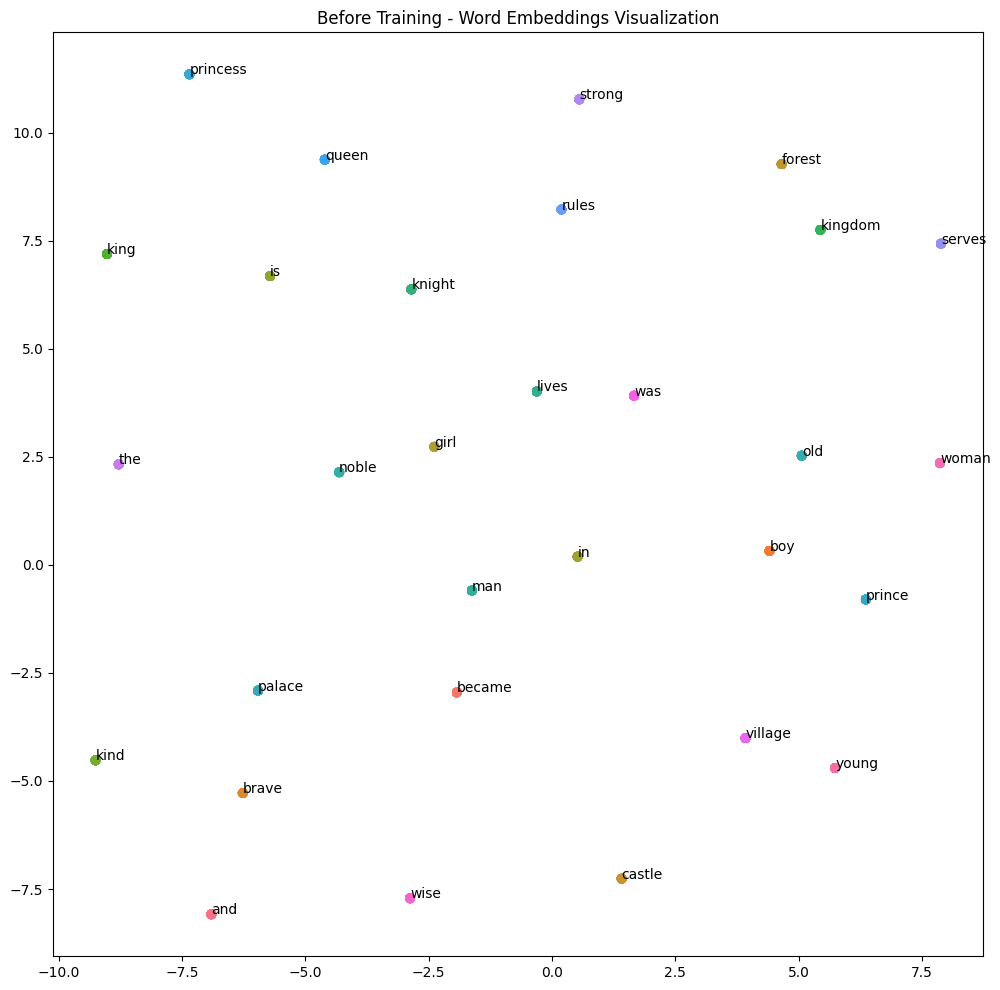

In [89]:
visualize_words_embedding(vocabulary, W1, word2index, "Before Training")


In [95]:
# start the training process
losses = []

for epoch in range(100):

    total_loss = 0 # restart loss to 0

    # iterate over batch size
    for i in range(0,len(X_train),batch_size):
        x = X_train[i:i+batch_size]
        y_true = y_train[i:i+batch_size]

        if len(x) < batch_size:
            break

        loss = train_batch_manual_pytorch(x, y_true, W1, W2, learning_rate, len(vocabulary))
        losses.append(loss)
        total_loss += loss

    if epoch % 10 == 0:
        print(f'Epoch num: {epoch+1}, loss value: {loss:.3f}')

Epoch num: 1, loss value: 2.603
Epoch num: 11, loss value: 2.603
Epoch num: 21, loss value: 2.603
Epoch num: 31, loss value: 2.603


KeyboardInterrupt: 

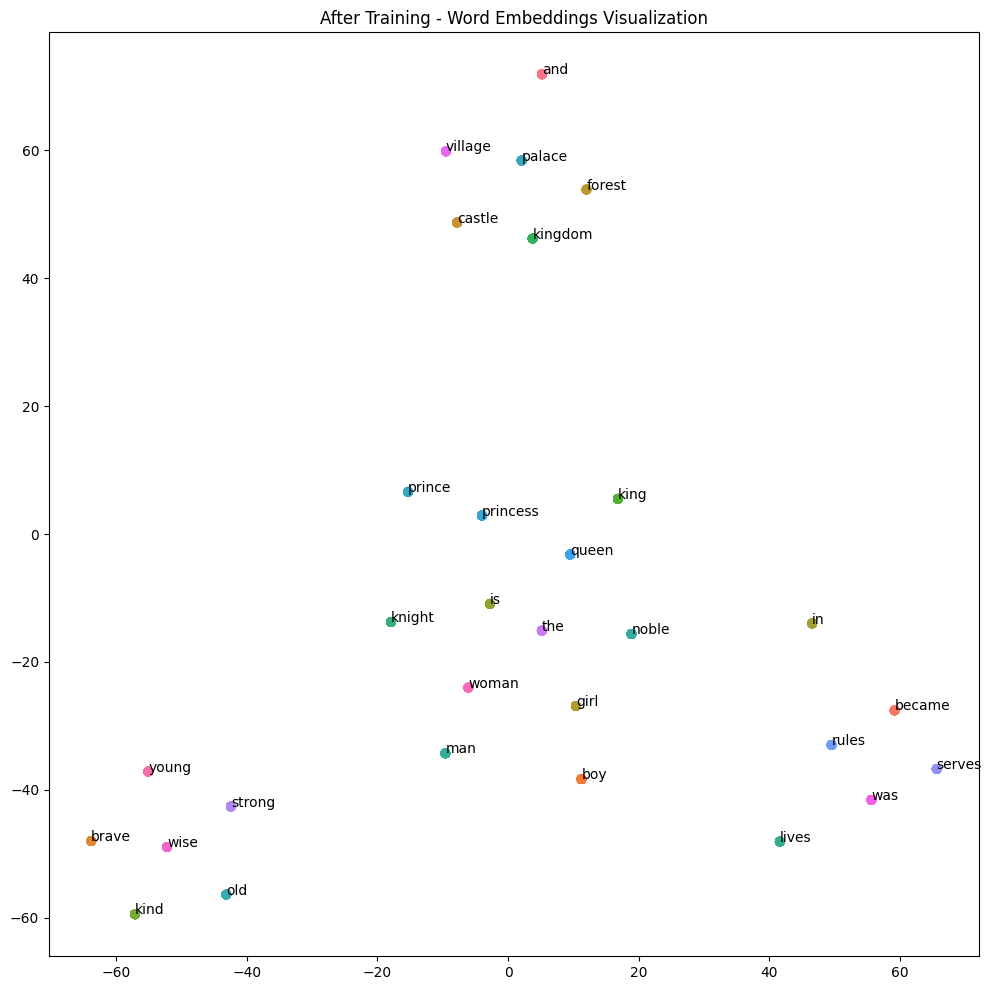

In [96]:

# visualize the word embeddings aftr training
visualize_words_embedding(words_to_visualize, W1, word2index, "After Training")


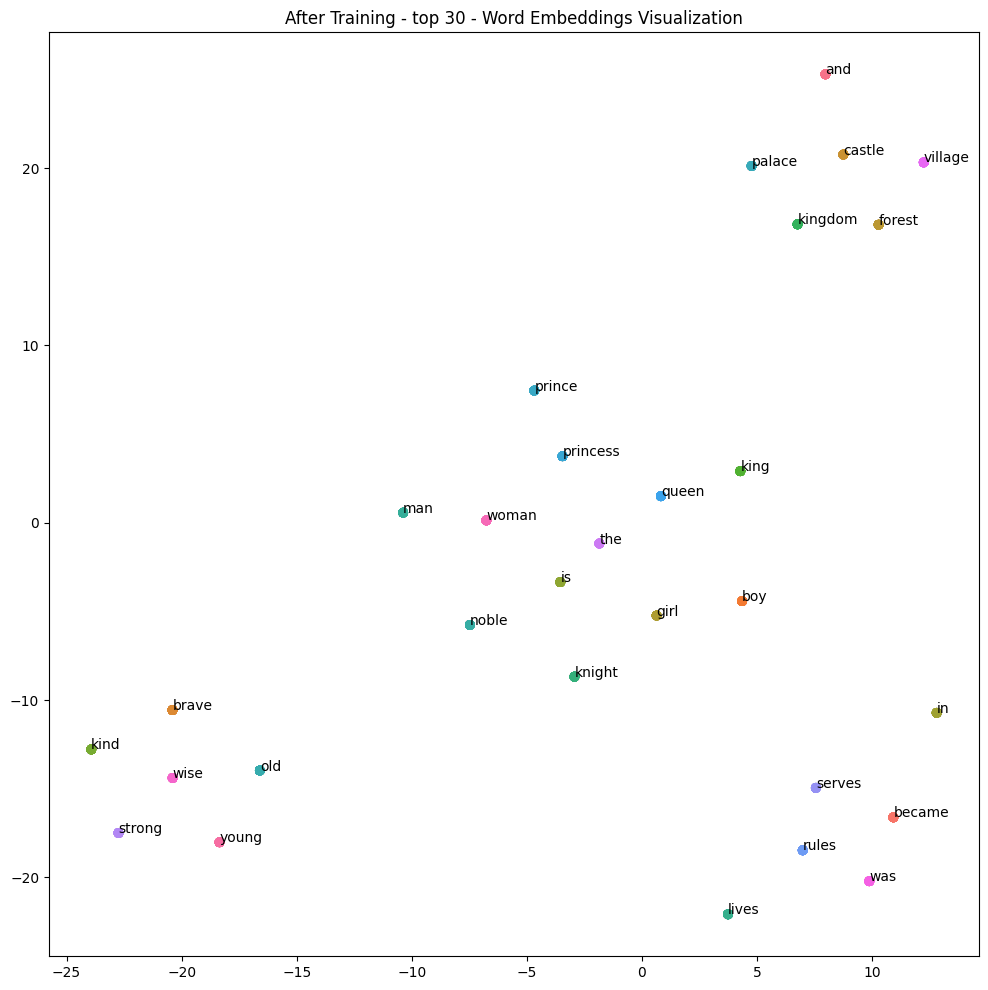

In [97]:
# show only top k
topk=30
top_indices = list(range(topk))
words_to_visualize = [index2word[i] for i in top_indices]
visualize_words_embedding(words_to_visualize, W1, word2index, f"After Training - top {topk}")

With the current settings, we see that it is able to distinguish semantic differences between objects, attributes, but clubbed all subects closer.
    

In [98]:
def find_analogy(w1, w2, w3, W1, stoi, itos, top_k=3):
    """
    Solves w1 - w2 + w3 = ?
    Example: King - Man + Woman = Queen
    """
    # 1. Get the vectors for the three words
    vec1 = W1[stoi[w1]]
    vec2 = W1[stoi[w2]]
    vec3 = W1[stoi[w3]]
    
    # 2. Perform the arithmetic: (King - Man + Woman)
    target_vec = vec1 - vec2 + vec3
    
    # 3. Compute Cosine Similarity between target_vec and ALL words in W1
    # Formula: (A . B) / (||A|| * ||B||)
    norm_W1 = torch.norm(W1, dim=1)           # Magnitude of every word vector
    norm_target = torch.norm(target_vec)       # Magnitude of our target
    
    # Dot product of target with every row in W1
    similarities = (W1 @ target_vec) / (norm_W1 * norm_target + 1e-9)
    
    # 4. Get the indices of the highest similarity scores
    values, indices = torch.topk(similarities, k=top_k + 3)
    
    print(f"Analogy: {w1} - {w2} + {w3} = ?")
    for idx in indices:
        word = itos[idx.item()]
        # Skip the input words themselves if they appear in the top results
        if word not in [w1, w2, w3]:
            print(f" -> {word} (score: {similarities[idx].item():.4f})")


In [99]:
find_analogy("king", "man", "woman", W1, word2index, index2word)

Analogy: king - man + woman = ?
 -> queen (score: 0.4013)
 -> is (score: 0.1658)
 -> princess (score: 0.1483)
 -> the (score: 0.1395)


Explained variance:  [0.25051003 0.1733537  0.09909907 0.05566417 0.04846257 0.04053546
 0.03400556 0.03302466 0.03145857 0.02425241]


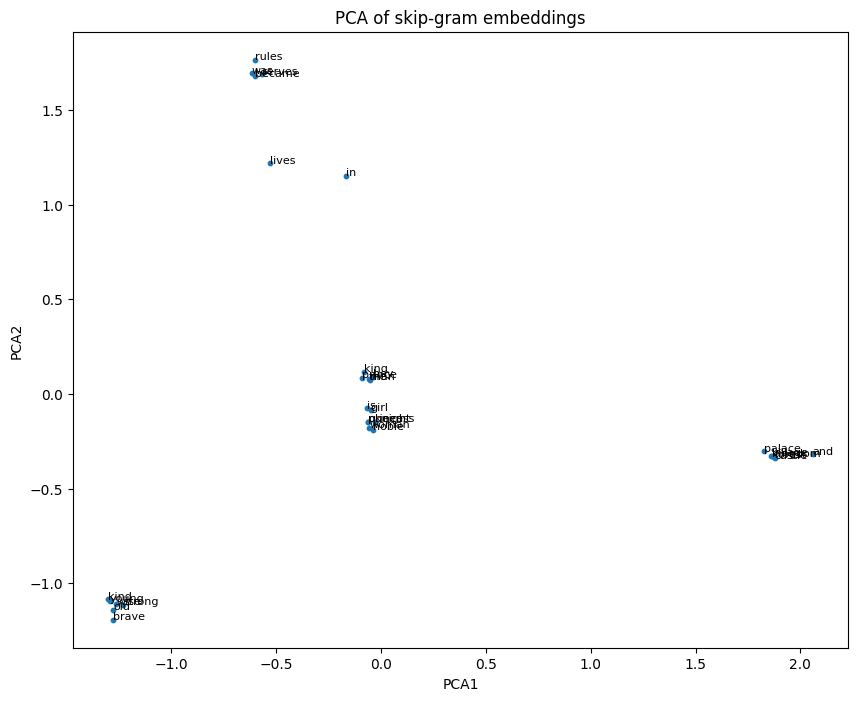

In [100]:
from sklearn.decomposition import PCA
import numpy as np
W1_centered = W1 - W1.mean(axis=0, keepdims=True)
pca = PCA(n_components=10)
Z = pca.fit_transform(W1_centered)
print("Explained variance: ", pca.explained_variance_ratio_)

pc1_scores  =  Z[:, 0]
top_idx = np.argsort(pc1_scores[-20:0])
bot_idx = np.argsort(pc1_scores[:20])

plt.figure(figsize=(10, 8))
plt.scatter(Z[:, 0], Z[:,1], s = 10)

for i, w in enumerate(vocabulary):
    plt.text(Z[i, 0], Z[i, 1], w, fontsize=8)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of skip-gram embeddings")
plt.show()

## Conclusion

Word2Vec is a masterclass in elegant problem design. The journey we've taken — from the orthogonality failure of one-hot vectors, through the distributional hypothesis, to a shallow neural network whose weights are the meaning — reveals a recurring pattern in machine learning: the right objective function, applied to the right data, produces structure we never explicitly programmed.

The Skip-Gram model doesn't learn what words mean. It learns what words predict — and it turns out that's the same thing.

## Appendices

### Derivative of Wx w.r.t x

Given: $\mathbf{s} = W \mathbf{\mathbf{x}}$

Find $\frac{\partial \mathbf{s}}{\partial \mathbf{x}}$.

Let the shape of W be $m \times n$. Shape of $\mathbf{x}$ is $n \times 1$ and shape of $\mathbf{s}$ is $m \times 1$. 

$s_i = \sum_{k=1}^{k=n} W_{i,k} x_k$.

In the denominator layout (of Jacobian), the derivative $\frac{\partial \mathbf{s}}{\partial \mathbf{x}}$ is of shape $n \times m$. The j-th row and i-th column contains $\frac{\partial \mathbf{s}_i}{\partial \mathbf{x}_j}$

Now, $\frac{\partial s_i}{\partial x_j} = W_{i,j}$ as the only term with k=j contains $x_j$

So, the j-th row and i-th column contains $W_{i,j}$. So the overall derivative matrix is $W^T$.

$\frac{\partial \mathbf{s}}{\partial \mathbf{x}} = W^T$

### Gradient of loss w.r.t weight matrix

A common operation in ML is taking the partial derivatives of a weight matrix w.r.t. a loss function. Let's derive it in this section.




First recall a couple of definitions:

**Kronecker product**

$A \in R^{p,q}$

$B \in R^{r, s}$

$A \otimes_{kron} B = \begin{bmatrix} a_{11} B &&  a_{12} B && \dots && a_{1q} B \\ \vdots \\ a_{p1} B &&  a_{p2} B && \dots && a_{pq} B \end{bmatrix}$

When A and B are vectors, say:

$A \in R^p$

$B \in R^q$

$A \otimes_{kron} B = \begin{bmatrix} a_{1} B  \\ \vdots \\ a_{p} B \end{bmatrix} = \begin{bmatrix} a_{1} b_1 \\ a_1 b_2 \\ \vdots \\ a_1 b_q \\ \vdots \\ a_{p} b_1 \\ a_p b_2 \\ \vdots \\ a_p b_q \end{bmatrix} = vec( A \otimes_{outer} B) $

**Outer product**


$A \in R^p$

$B \in R^q$

$A \otimes_{outer} B = \begin{bmatrix} a_1 b_1 && a_1 b_2 && \dots && a_1 b_q  \\ \vdots \\ a_p b_1 && a_p b_2 && \dots && a_p b_q\end{bmatrix} = reshape(A \otimes_{kron} B)$

Also, notice that $A \otimes_{outer} B = A@B^T$.


Now to the actual problem:

Given a composite function: $L(\mathbf{s}(W))$ such that
* L is a multi-variate scalar valued function
* W is a matrix of shape $V \times d$
* $\mathbf{s}$ is a muiti-variate, vector valued function with output shape $V \times 1$.

Find the Jacobian of L w.r.t. W (i.e., partial derivatives of L w.r.t W) in denominator layout.

Here the Jacobian is:

$\mathcal{J}(L) = \begin{bmatrix} \frac{\partial L}{\partial W_{11}} && \frac{\partial L}{\partial W_{12}} &&  \dots && \frac{\partial L}{\partial W_{1d}} \\ \frac{\partial L}{\partial W_{21}} &&  \frac{\partial L}{\partial W_{22}} && \dots &&  \frac{\partial L}{\partial W_{2d}} \\ \vdots \\ \frac{\partial L}{\partial W_{V1}} &&  \frac{\partial L}{\partial W_{V2}} && \dots && \frac{\partial L}{\partial W_{Vd}} \end{bmatrix}$


Using chain rule,

$\frac{\partial L}{\partial W_{11}} = \frac{\partial L}{\partial s_{1}} * \frac{\partial s_1}{\partial W_{11}} + \frac{\partial L}{\partial s_{2}} * \frac{\partial s_2}{\partial W_{11}} + \dots + \frac{\partial L}{\partial s_{V}} * \frac{\partial s_V}{\partial W_{11}}$

$\frac{\partial L}{\partial W_{12}} = \frac{\partial L}{\partial s_{1}} * \frac{\partial s_1}{\partial W_{12}} + \frac{\partial L}{\partial s_{2}} * \frac{\partial s_2}{\partial W_{12}} + \dots + \frac{\partial L}{\partial s_{V}} * \frac{\partial s_V}{\partial W_{12}}$

and so on...

$\frac{\partial L}{\partial W_{ij}} = \frac{\partial L}{\partial s_{1}} * \frac{\partial s_1}{\partial W_{ij}} + \frac{\partial L}{\partial s_{2}} * \frac{\partial s_2}{\partial W_{ij}} + \dots + \frac{\partial L}{\partial s_{V}} * \frac{\partial s_V}{\partial W_{ij}}$

to...

$\frac{\partial L}{\partial W_{Vd}} = \frac{\partial L}{\partial s_{1}} * \frac{\partial s_1}{\partial W_{Vd}} + \frac{\partial L}{\partial s_{2}} * \frac{\partial s_2}{\partial W_{Vd}} + \dots + \frac{\partial L}{\partial s_{V}} * \frac{\partial s_V}{\partial W_{Vd}}$


We have  a total of Vd terms.

Instead of dealing with terms individually, we can use matrix to succinctly represent and operate on them. And if you notice the above line up, you can see that they can be written as:


$\begin{bmatrix} \frac{\partial L}{\partial W_{11}} \\ \frac{\partial L}{\partial W_{12}} \\ \vdots \\ \frac{\partial L}{\partial W_{ij}} \\ \vdots \\ \frac{\partial L}{\partial W_{Vd}}\end{bmatrix} = \begin{bmatrix} \frac{\partial s_1}{\partial W_{11}}  && \frac{\partial s_2}{\partial W_{11}} &&  \dots && \frac{\partial s_V}{\partial W_{11}} \\ \frac{\partial s_1}{\partial W_{12}}  && \frac{\partial s_2}{\partial W_{12}} &&  \dots && \frac{\partial s_V}{\partial W_{12}} \\ \vdots \\ \frac{\partial s_1}{\partial W_{ij}}  && \frac{\partial s_2}{\partial W_{ij}} &&  \dots && \frac{\partial s_V}{\partial W_{ij}} \\ \vdots \\  \frac{\partial s_1}{\partial W_{Vd}}  && \frac{\partial s_2}{\partial W_{Vd}} &&  \dots && \frac{\partial s_V}{\partial W_{Vd}}\end{bmatrix} @ \begin{bmatrix} \frac{\partial L}{\partial s_{1}} \\ \frac{\partial L}{\partial s_{2}} \\ \vdots \\ \frac{\partial L}{\partial s_{V}}\end{bmatrix}$


Note that LHS is the partial derivatives of L over all Vd elements of W as a column matrix. So, if $W_v = vec(W)$ where vec means vectorizing a matrix, the above equation can be written as:

$\frac{\partial L}{\partial W_v}  = \frac{\partial s}{\partial W_v} @ \frac{\partial L}{\partial \mathbf{s}} $

But we need to relayout so that the LHS is in the desired form (V x d). So,

Our desired Jacobian is: $\boxed{\mathcal{J}(L) = reshape(\frac{\partial L}{\partial W_v}, (V, d)) = reshape(\frac{\partial s}{\partial W_v} @ \frac{\partial L}{\partial \mathbf{s}}, ( V, d))}$

Note that we cannot make any more simplifications till we know what the L, $\mathbf{s}$ functions are.

Let's take a look at a sample $\mathbf{s}$, say $\mathbf{s}=W\mathbf{x}$ for some $\mathbf{x}$ of shape $d \times 1$. Hence W is of $V \times d$ and $\mathbf{s}$ will be of $V \times 1$. Here $\mathbf{x}$ is a `constant`.

$s_1 = W_{11}x_1 + W_{12}x_2 + W_{13}x_3 + \dots + W_{1d} x_d$

...

$s_V = W_{V1}x_1 + W_{V2}x_2 + W_{V3}x_3 + \dots + W_{Vd} x_d$

Then $\frac{\partial s_1}{\partial W_{11}} = x_1$, $\frac{\partial s_1}{\partial W_{12}} = x_2$, $\frac{\partial s_1}{\partial W_{21}} = 0$ and so on, a total of Vd terms.

So, $\frac{\partial \mathbf{s}}{\partial W_v}$ becomes (notice that $\mathbf{s}$ is $V \times 1$:

$\frac{\partial \mathbf{s}}{\partial W_v}  = \begin{bmatrix} x_1 && 0 && \dots && V-times \\ x_2 && 0 && \dots && V-times \\ \vdots \\ x_d && \dots && V-times \\ \vdots \\ 0 && x_1 && \dots \\ 0 && x_2 && \dots \\ \vdots \\ 0 && x_d && 0 \dots \\ \vdots \\ 0 && 0 && 0 && (V-1) times &&  x_1 \\ 0 && 0 && 0 && (V-1) times &&  x_2 \\ \vdots \\ 0 && 0 && 0 && (V-1) times &&  x_d \end{bmatrix} = I_{V \times V} \otimes_{kron} \mathbf{x}$

This is of shape $Vd \times V$

If we post-multiply with $\frac{\partial L}{\partial \mathbf{s}}$ (we can do since they are $Vd \times V$ and $V \times 1$ resulting in a $Vd \times 1$ matrix)

$\frac{\partial L}{\partial W_v} = \frac{\partial \mathbf{s}}{\partial W_v} @ \frac{\partial L}{\partial \mathbf{s}} = \begin{bmatrix} x_1 \frac{\partial L}{\partial s_1} \\ x_2 \frac{\partial L}{\partial s_1} \\ x_3 \frac{\partial L}{\partial s_1} \\ \vdots \\ x_d \frac{\partial L}{\partial s_1} \\ \vdots \\ x_1 \frac{\partial L}{\partial s_V} \\ x_2 \frac{\partial L}{\partial s_V} \\ x_3 \frac{\partial L}{\partial s_V} \\ \vdots \\ x_d \frac{\partial L}{\partial s_V} \end{bmatrix} = \frac{\partial L}{\partial \mathbf{s}} \otimes_{kron} \mathbf{x}$

So $\frac{\partial L(\mathbf{s}(W))}{\partial W} = reshape(\frac{\partial L}{\partial W_v}, (V, d)) = reshape(\frac{\partial L}{\partial \mathbf{s}} \otimes_{kron} \mathbf{x}, (V, d)) = \frac{\partial L}{\partial \mathbf{s}} \otimes_{outer} \mathbf{x} = \frac{\partial L}{\partial \mathbf{s}} @ \mathbf{x}^T$ (because both parameters to kronecker are vectors). The layout matches that of W so you can simply subtract a fraction of this matrix during weight updates after gradient calculations. Our final derivation is:

$\boxed{\frac{\partial L(\mathbf{s}(W))}{\partial W} = \frac{\partial L}{\partial \mathbf{s}} @ \mathbf{x}^T}$ where $\mathbf{s}=W\mathbf{x}$, for some constant $\mathbf{x}$.


### Parameter sizes

**Parameters**

The model has two embedding matrices:

$W \in \mathbb{R}^{V \times d}$ — center word embeddings
$W' \in \mathbb{R}^{V \times d}$ — context word embeddings
Total free parameters:

$$|\theta| = 2 \times V \times d$$

For typical values $V = 50{,}000$ and $d = 300$:

$$|\theta| = 2 \times 50{,}000 \times 300 = 30{,}000{,}000 \quad (30\text{M parameters})$$



**Constraints**

Let $w_t, w_c$ be the OHE of a target/center word and a context word respectively.

Each $(w_t, w_c)$ training pair generates one constraint: "the model should assign high probability to $w_c$ given $w_t$." The number of such pairs depends on the corpus size $T$ and window size $2m$:

$$\text{Training pairs} \approx T \times 2m$$

For a Wikipedia-scale corpus with $T = 1{,}000{,}000{,}000$ words and $m = 5$:

$$\text{Constraints} \approx 10^9 \times 10 = 10^{10} \quad (10\text{ billion pairs})$$

Ratio of constraints to parameters:

$$\frac{10^{10}}{3 \times 10^7} \approx 333\times \text{ more constraints than parameters}$$ (from training pairs perspective)

The system is massively over-determined from this perspective. There is no exact solution — gradient descent finds the best compromise.


The massive over-determination is not a problem — it is what makes the embeddings generalize. With far more constraints than parameters, the model cannot memorize individual word pairs. It is forced to find a compact, shared structure that satisfies as many constraints as possible simultaneously. That shared structure is the semantic geometry of the embedding space.

This is the same reason that a linear regression with 1 million data points and 10 features generalizes well: the over-determination forces the model to find the true underlying pattern rather than overfit to noise.

The flip side — as we discussed earlier — is that zero loss is impossible: with $83\times$ (from matrix factorization perspective, $|V|^2$ entries vs. 2|V|d parameters) more constraints than degrees of freedom, the system is fundamentally under-constrained in its ability to satisfy all targets exactly. The residual loss is the irreducible price of compression.


### Transformer

We still have a couple of shortcomings even if we encode words using word2vec.

**Shortcoming 1**: Similarity Doesn't Distinguish Synonyms from Antonyms

Word2Vec learns embeddings by placing words that appear in similar contexts close together in vector space. But consider:

"The temperature was extreme — it was scorching hot." "The temperature was extreme — it was freezing cold."

Both hot and cold appear near temperature, extreme, weather, degrees. Their context neighborhoods are nearly identical — so Word2Vec places them close together in embedding space. But hot and cold are antonyms, not synonyms.

The distributional hypothesis captures topical relatedness, not semantic polarity. Words that are opposites tend to be used in the same contexts (you talk about hot and cold in the same conversations). A single static embedding space often conflates topical relatedness with semantic opposition. Distinguishing these relations typically requires richer supervision or architectures.

Partial fix: multiple vector spaces. We can represent each word simultaneously in multiple independent vector spaces — for example:

* A semantic space where hot and cold are pushed to opposite ends (perhaps supervised by sentiment or polarity labels)
* A topical space where hot, cold, and temperature all cluster together

In the semantic space, $\text{sim}(\vec{\text{hot}}, \vec{\text{cold}}) \approx -1$. In the topical space, $\text{sim}(\vec{\text{hot}}, \vec{\text{cold}}) \approx +1$. Different spaces capture different aspects of meaning. This is the intuition behind multi-sense embeddings and models like ELMo, which produce different vectors for the same word depending on context.

**Shortcoming 2**: Similarity Is Symmetric, But Attention Is Not

Now consider the sentence:

"He picked up the tennis ball and found it was wet."

We want to resolve what "it" refers to. Intuitively:

"it" should pay strong attention to "ball" (that's its referent)
"ball" should pay moderate attention to "tennis" (its modifier)
"ball" should pay weak attention to "it" (a pronoun referring back to it)

But cosine similarity is symmetric and commutative:

$$\text{sim}(\vec{\text{it}}, \vec{\text{ball}}) = \text{sim}(\vec{\text{ball}}, \vec{\text{it}})$$

The strength of the relationship is the same in both directions. This is fine for measuring semantic relatedness, but it's wrong for directed attention — the degree to which one word should attend to another is inherently asymmetric. "it" needs "ball" more than "ball" needs "it".

The Fix: Split the Attention Space into Keys and Queries

The solution is to give each word two separate representations in the attention space:

* A Query vector $\mathbf{q}_w \in \mathbb{R}^{d_k}$: represents the word as an attendee — "what am I looking for?"
* A Key vector $\mathbf{k}_w \in \mathbb{R}^{d_k}$: represents the word as a target of attention — "what do I offer to others?"
The attention score from word $i$ attending to word $j$ is then:

$$\text{score}(i \to j) = \mathbf{q}_i \cdot \mathbf{k}_j$$

This is asymmetric by construction:

$$\mathbf{q}_i \cdot \mathbf{k}_j \neq \mathbf{q}_j \cdot \mathbf{k}_i \quad \text{in general}$$

For our example:

* $\mathbf{q}{\text{it}} \cdot \mathbf{k}{\text{ball}}$ is large — "it" is querying for a concrete noun referent, and "ball" is a strong key match
* $\mathbf{q}{\text{ball}} \cdot \mathbf{k}{\text{it}}$ is small — "ball" is not looking for a pronoun

The query and key vectors live in the same $d_k$-dimensional space (so the dot product is defined), but they are learned independently — a word's query vector and key vector are generally different.

Putting It All Together: Three Spaces per Word

This gives us a picture where each word simultaneously inhabits three vector spaces:


| Space | Vector | Role | Dimension |
|---|---|---|---|
| Semantic / content space | $\mathbf{v}_w$ | What the word *means* | $d_v$ |
| Query space | $\mathbf{q}_w$ | What the word *attends to* | $d_k$ |
| Key space | $\mathbf{k}_w$ | What *attends to* the word | $d_k$ |


In the Transformer architecture, there is actually a fourth vector — the Value vector $\mathbf{v}_w^{\text{val}} \in \mathbb{R}^{d_v}$ — which represents the content that gets passed forward once attention weights are computed:

$$\text{Attention}(Q, K, V) = \text{softmax}!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The $\frac{1}{\sqrt{d_k}}$ scaling prevents the dot products from growing too large in high dimensions (which would push the softmax into saturation).

The Conceptual Arc:


| Representation | Captures | Limitation |
|---|---|---|
| One-hot | Word identity | No relationships at all |
| Word2Vec embedding | Topical/distributional similarity | Symmetric; conflates antonyms with synonyms |
| Multi-space embeddings | Multiple aspects of meaning | Still symmetric within each space |
| Query + Key vectors | Directed, asymmetric attention | ✅ Solves both shortcomings |


Word2Vec asks: "which words tend to appear together?" Attention asks: "given this word, which other words should it focus on — and how strongly?"

The shift from similarity to attention is the conceptual leap that separates Word2Vec from the Transformer. And as you've shown, it arises naturally from asking: "what does similarity get wrong, and how do we fix it?"


**Shortcoming 3**: word2vec gnore the order in which context words occur, we just limit to happening them in a given window.

Positional encoding in transformer architecture addresses this.

### Embeddings as Low-Rank Matrix Factorization

Reducing from vocabulary size $|V|$ to embedding dimension $d$ is conceptually identical to low-rank matrix factorization. Here's why.

The one-hot matrix for a vocabulary is simply the identity matrix $I \in \mathbb{R}^{|V| \times |V|}$ — full rank, no shared structure, every word completely independent. Multiplying by the embedding matrix $W \in \mathbb{R}^{|V| \times d}$ (where $d \ll |V|$) projects this into a $d$-dimensional space:

$$E = I \cdot W = W \in \mathbb{R}^{|V| \times d}$$

The result has rank at most $d$ — a low-rank approximation of the full word co-occurrence structure. This is precisely the idea behind Latent Semantic Analysis (LSA), which applies SVD to a word co-occurrence matrix $M$:

$$M \approx U_d \Sigma_d V_d^T$$

where the rows of $U_d \in \mathbb{R}^{|V| \times d}$ are the $d$-dimensional word embeddings.

The connection to Word2Vec was made precise by Levy & Goldberg (2014), who showed that Skip-Gram with Negative Sampling implicitly factorizes the Pointwise Mutual Information (PMI) matrix of word-context co-occurrences:

$$W \cdot W'^T \approx M^{\text{PMI}} - \log k$$

where $k$ is the number of negative samples. So Word2Vec is doing matrix factorization — but implicitly, through stochastic gradient descent on a prediction objective, rather than explicitly via SVD.

> | Approach | Method | Matrix Factorized |
> |---|---|---|
> | LSA | Explicit SVD | Raw co-occurrence counts |
> | GloVe | Explicit factorization | Log co-occurrence counts |
> | Word2Vec SGNS | Implicit via SGD | Shifted PMI matrix |

These methods are closely related in that they all exploit low-rank structure in word co-occurrence statistics, though they optimize different objectives and are not identical procedures.

The Geometric Intuition:

SVD finds the directions of maximum variance in the data — the axes along which words vary most in their co-occurrence patterns. The top $d$ singular vectors capture the most important latent dimensions of meaning. Word2Vec finds a similar low-dimensional structure, but through a different (and more scalable) optimization path.

This is why both methods produce embeddings where similar words are close together: they are both discovering the same underlying low-rank structure in language, just via different routes.

More details:


**Are We Solving an Over-Specified Linear Algebra Problem?**

The Setup

When we train a Word2Vec Skip-Gram network, we are looking for two matrices:

$$W \in \mathbb{R}^{|V| \times d} \quad \text{(target embeddings)}$$ $$W' \in \mathbb{R}^{|V| \times d} \quad \text{(context embeddings)}$$

The product $W \cdot W'^T \in \mathbb{R}^{|V| \times |V|}$ should approximate the PMI matrix of word-context co-occurrences (as Levy & Goldberg showed). That target matrix has $|V|^2$ entries. But our two embedding matrices together have only $2 \cdot |V| \cdot d$ free parameters.

For a typical vocabulary of $|V| = 50{,}000$ and $d = 300$:

Entries to approximate: $50{,}000^2 = 2.5 \times 10^9$
Free parameters: $2 \times 50{,}000 \times 300 = 30{,}000{,}000$
We have roughly 83× fewer parameters than constraints. So yes — this is a massively under-determined (not over-specified) system in the sense that we cannot exactly satisfy all constraints simultaneously. We are forced to find the best low-rank approximation.

**The Correct Framing: Under-Determined, Not Over-Specified**

The terminology matters here:

* Over-specified (over-determined): more equations than unknowns — no exact solution exists, we find a least-squares best fit
* Under-determined: fewer equations than unknowns — infinitely many exact solutions exist, we need a regularizer to pick one
* What Word2Vec actually is: a combination of both, depending on how you look at it
From the matrix factorization perspective: we have $|V|^2$ target values but only $2|V|d$ parameters — this is over-determined in the sense that we cannot fit all targets exactly with a rank-$d$ matrix. We are finding the best rank-$d$ approximation, exactly like truncated SVD.

From the neural network optimization perspective: the loss function is non-convex, the gradient descent trajectory is stochastic, and the solution is not unique — many different $(W, W')$ pairs achieve similar loss values. This is under-determined in the sense that the solution is not unique.

**The Deeper Connection: Why Low Rank Works**

The reason this works at all — why a rank-$d$ approximation captures meaningful structure — is that the true PMI matrix is approximately low rank. Language has far fewer independent dimensions of meaning than it has words. The top singular vectors of the co-occurrence matrix capture the dominant semantic axes: topics, syntactic roles, sentiment, etc. Everything else is noise.

This is the same reason PCA works for faces, or why a 300-dimensional embedding can represent 50,000 words: the intrinsic dimensionality of the data is much lower than its surface dimensionality.

Formally, if the true PMI matrix $M$ has effective rank $r \ll |V|$, then:

$$M \approx U_r \Sigma_r V_r^T$$

and any $d \geq r$ gives a near-perfect approximation. In practice, $d = 300$ captures most of the meaningful variance.

**The Gradient Descent as an Implicit Regularizer**

There's one more subtlety. Even if we set $d$ large enough that the system is under-determined (infinitely many solutions), stochastic gradient descent with random initialization tends to find solutions with a specific character — it implicitly prefers solutions with small norm (a form of implicit $L_2$ regularization). One possible interpretation is that the low-dimensional parameterization and SGD dynamics together provide an implicit regularizing effect.

| Perspective | System Type | What We're Solving |
|---|---|---|
| Matrix factorization | Over-determined | Best rank-$d$ approximation of PMI matrix |
| Neural network optimization | Under-determined | One of many local minima of a non-convex loss |
| Geometric | Low-rank recovery | Finding the intrinsic low-dimensional structure of language |

So the most precise answer is: we are solving a best low-rank approximation problem — conceptually identical to truncated SVD, but done implicitly through stochastic gradient descent rather than explicitly through eigendecomposition. The "over-specification" you're sensing is real: we have far more constraints (word pairs) than parameters, and we resolve the conflict by accepting a low-rank approximation that captures the dominant structure and discards the noise.




### The Probability Distribution Assumed in Word2Vec

Word2Vec assumes a categorical (multinomial) distribution over the vocabulary at each prediction step. Specifically, for a given center word $t$, the model assumes that each context word $c$ is drawn independently from a categorical distribution over all $|V|$ words:

$$c \sim \text{Categorical}(P(\cdot \mid t))$$

where the probabilities are given by the softmax:

$$P(c \mid t) = \frac{\exp(\mathbf{u}_c^T \mathbf{v}_t)}{\sum{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)}$$

What This Means in Detail:

A categorical distribution is the generalization of a Bernoulli distribution to more than two outcomes. It assigns a probability $p_i$ to each of $|V|$ possible outcomes (words), with $\sum_{i=1}^{|V|} p_i = 1$. Drawing one sample from it gives you exactly one word — the predicted context word.

The softmax is the canonical parameterization of the categorical distribution using real-valued scores (logits). Given raw scores $s_w = \mathbf{u}_w^T \mathbf{v}_t$, the softmax maps them to valid categorical probabilities:

$$P(c \mid t) = \text{softmax}(s)_c = \frac{e^{s_c}}{\sum_w e^{s_w}}$$

This is not an arbitrary choice — it is the maximum entropy distribution subject to the constraint that the expected sufficient statistics (the dot products) match the observed ones. In other words, softmax is the least assumptive distribution consistent with the linear scoring model.

The Independence Assumption:

A critical and often overlooked assumption: Word2Vec treats all context words within a window as conditionally independent given the center word. For a window of size $m$, the joint probability of all context words is:

$$P(w_{t-m}, \ldots, w_{t-1}, w_{t+1}, \ldots, w_{t+m} \mid w_t) = \prod_{\substack{-m \leq j \leq m \ j eq 0}} P(w_{t+j} \mid w_t)$$

This is a naive Bayes-style independence assumption — the same simplification used in naive Bayes classifiers. It is almost certainly wrong (context words are not independent of each other), but it makes the objective tractable and, empirically, produces excellent embeddings anyway.

The Log-Likelihood Connection:

Given this categorical distribution, the maximum likelihood estimator is exactly the objective Word2Vec optimizes. For a single (center, context) pair, the log-likelihood is:

$$\log P(c \mid t) = s_c - \log \sum_{w \in V} e^{s_w} = \mathbf{u}_c^T \mathbf{v}_t - \log Z(t)$$

Maximizing this over the corpus is equivalent to minimizing the negative log-likelihood $\mathcal{L}$ derived in Section 5.3. So the loss function is not an ad hoc choice — it is the exact negative log-likelihood of the assumed categorical model.

The Exponential Family Connection:

For readers with a statistics background: the softmax parameterization places this model in the exponential family. The categorical distribution with natural parameters $\boldsymbol{\eta} = (\mathbf{u}_1^T \mathbf{v}_t, \ldots, \mathbf{u}_{|V|}^T \mathbf{v}_t)$ has:

Sufficient statistic: the one-hot vector of the observed context word

* Log-partition function: $\log Z(t) = \log \sum_w e^{\mathbf{u}_w^T \mathbf{v}_t}$
* MLE condition: the gradient of the log-partition equals the expected sufficient statistic — which is exactly the gradient we derived in Section 6.1

This is why the gradient has the elegant form $\frac{\partial \mathcal{L}}{\partial \mathbf{v}_t} = -\mathbf{u}_c + \mathbb{E}{w \sim P(\cdot|t)}[\mathbf{u}_w]$: it is the standard score equation of an exponential family model, which sets the observed sufficient statistic equal to its expectation under the model.

| Assumption | What It Is | Where It Appears |
|---|---|---|
| Distribution over context words | Categorical | Softmax output |
| Parameterization | Exponential family (softmax) | $P(c \mid t) = \text{softmax}(\mathbf{u}^T \mathbf{v}_t)_c$ |
| Independence of context words | Naive Bayes | Product over window positions |
| Estimation principle | Maximum likelihood | Negative log-likelihood loss |


The entire mathematical structure of Word2Vec — the softmax, the loss function, the gradient form — falls out naturally once you commit to modeling context words as draws from a categorical distribution parameterized by dot products. Everything else is just calculus.



### Zero Loss Is Impossible — and That's a Feature, Not a Bug

Why Zero Loss Would Be Catastrophic

The Skip-Gram loss for a single (center, context) pair is:

$$\mathcal{L} = -\log P(c \mid t) = -\log \frac{\exp(\mathbf{u}_c^T \mathbf{v}t)}{\sum{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)}$$

For this loss to reach zero, we would need $P(c \mid t) = 1$, which means:

$$\frac{\exp(\mathbf{u}_c^T \mathbf{v}t)}{\sum{w \in V} \exp(\mathbf{u}_w^T \mathbf{v}_t)} = 1$$

This requires the numerator to equal the denominator — meaning every other term in the sum must be zero:

$$\exp(\mathbf{u}_w^T \mathbf{v}_t) = 0 \quad \text{for all } w eq c$$

But $\exp(\cdot) > 0$ always — the exponential function is strictly positive for all finite inputs. The only way to drive $\exp(\mathbf{u}_w^T \mathbf{v}_t) \to 0$ is to send $\mathbf{u}_w^T \mathbf{v}_t \to -\infty$, which requires the vectors to have infinite magnitude. That would mean the weights blow up to infinity — a catastrophic divergence of the model.

Why It's Impossible?

So zero loss is impossible for two compounding reasons:

* The softmax denominator is always strictly greater than the numerator (since it sums over all $|V|$ words, each contributing a positive term). Therefore $P(c \mid t) < 1$ always, and $-\log P(c \mid t) > 0$ always.
* Achieving $P(c \mid t) = 1$ would require infinite weight magnitudes, which gradient descent with finite learning rates can never reach in finite steps.

The Deeper Issue: Conflicting Supervision

There's an even more fundamental reason zero loss is unattainable in practice. The same word $c$ appears as a context word for many different center words — and also as a center word itself, generating its own context predictions. The training pairs are mutually contradictory:

* Pair $(t_1, c)$ says: "given $t_1$, predict $c$ with high probability" — pushes $\mathbf{u}c$ toward $\mathbf{v}{t_1}$
* Pair $(t_2, c)$ says: "given $t_2$, predict $c$ with high probability" — pushes $\mathbf{u}c$ toward $\mathbf{v}{t_2}$
* Pair $(t_3, w eq c)$ says: "given $t_3$, do NOT predict $c$" — pulls $\mathbf{u}c$ away from $\mathbf{v}{t_3}$

These constraints cannot all be simultaneously satisfied with finite vectors. The model settles into a compromise — a configuration that satisfies the most important constraints as well as possible. This compromise is the embedding space. The residual loss encodes the irreducible ambiguity of language.

Why This Is a Feature?

The impossibility of zero loss is not a failure — it is what makes the embeddings meaningful:

If the model could perfectly predict every context word, it would have memorized the training corpus rather than learned generalizable structure.
The compression forced by the finite embedding dimension $d$ and the impossibility of zero loss together ensure that the model must find shared structure across words — which is exactly the semantic geometry we want.
In this sense, Word2Vec embeddings are the optimal lossy compression of the distributional structure of language into a $d$-dimensional space. The loss that remains is the price of compression; the structure that emerges is the reward.



### Brief Contrast with CBOW

The Continuous Bag of Words (CBOW) model inverts the task: given the surrounding context words, predict the center word. If Skip-Gram asks "given fox*, what words appear nearby?", CBOW asks "given the words the, quick, jumps, over, what is the center word?"*

In practice, Skip-Gram often performs better on rare words, while CBOW is usually faster and can work well for frequent words.

Word2Vec, Skip-Gram, and CBOW: What's What ?

Word2Vec is the framework — the overall system and training methodology introduced by Mikolov et al. (2013) at Google. It is not a single algorithm; it is an umbrella that contains two distinct model architectures:

Skip-Gram — given a center word, predict its surrounding context words
CBOW (Continuous Bag of Words) — given surrounding context words, predict the center word
So the relationship is:

```
Word2Vec
├── Skip-Gram
└── CBOW
```

Think of Word2Vec as the recipe book, and Skip-Gram / CBOW as two different recipes inside it. Both recipes share the same core idea — use a shallow neural network trained on a prediction task to produce dense word embeddings — but they differ in the direction of the prediction.

Side by side comparison:

  | | Skip-Gram | CBOW |
|---|---|---|
| **Input** | One center word | Multiple context words (averaged) |
| **Output** | Predict surrounding context words | Predict the center word |
| **Training signal** | One center → many context pairs | Many context → one center |
| **Works better for** | Rare words, small datasets | Frequent words, large datasets |
| **Computational cost** | Higher (predicts multiple outputs) | Lower (averages inputs, one output) |
| **Typical use** | Research, rigorous derivation | Production, speed-sensitive settings |  



The Intuition for Why They Differ

Skip-Gram treats each (center, context) pair as a separate training example. For a window of size 2, one center word generates up to 4 training pairs. This means rare words get more training signal — they appear as the center word in many pairs even if they don't appear often in the corpus.

CBOW averages the context word vectors and predicts the center. The averaging smooths out noise and makes training faster, but it also loses information about the order and individual contribution of each context word. Rare words get less focused training signal.

A Useful Analogy

Word2Vec is like saying "we'll learn word meanings by playing a guessing game with text."
Skip-Gram is the version where you're given a word and must guess its neighbors — like being shown "fox" and guessing "quick," "brown," "jumps."
CBOW is the version where you're given the neighbors and must guess the center word — like being shown "quick," "brown," "jumps" and guessing "fox."
Same game, opposite direction.

## Positive Semi Definite (PSD)

Let's say we naively try to use a single embeddings for our skip-gram model, W of size $V \times d$ instead of W and W'.

The score matrix becomes $S = WW^T$. The input is a V dimensional vector, and we want an output vector of V dimensions representing scores that we convert into probabilities using softmax. So this is appropriate here. This also means S is a symmetric matrix $S^T = (WW^T)^T = (W^T)^TW^T = WW^T = S$

A matrix of this form is called positve semi definite: For any vector $\mathbf{z}$ of size $V \times 1$, $\mathbf{z}^TS\mathbf{z} = \mathbf{z}^T(WW^T)\mathbf{z} = (W^T\mathbf{z})^T(W^T\mathbf{z}) = ||W^T\mathbf{z}||^2 \ge 0$

* In this representation because shared W, the scores of a context and center word similar irrespective of their role as context or center word, S[i, j] = S[j, i].
* It is non-negative quadratic form, $\mathbf{z}^TS\mathbf{z} \ge 0$ for all $\mathbf{z}$. 
* The embeddings end up living in a single Euclidean space where dot products define similarty

So, PSD severly limits on what relationships can the model represent:
* We want directional context (subject vs. object) and hence different strengths based on role
* Word frequency is not uniform (Zipf's law)
* In English where more than 40% words are polysemy (word like `bank` having different meanings in different contexts), PSD creates transitive-trelationships that are not desirable (bank ~ river, bank ~ money leading to river ~ money).
   
Instead of PSD, the bilinear form $S = WW'^T$ allows asymmetry (context vs. center role played by a word) and allows for independent geometric spaces. It gives more degrees of freedom (more parameters to play with).

The design of skip-gram creates a low rank matrix (<= d being smaller than V), but symmetric adds ADDITIONAL constraint that only PSD matrices are considered. 

If we tie the two embedding matrices, then the score matrix becomes $WW^T$, which is necessarily symmetric positive semidefinite and rank at most d. Using separate matrices allows a more general low-rank score matrix $WW'^T$, which need not be symmetric.

A (not that useful) side note: Since usually $d \lt\lt V$, $WW^T$ is usually PSD not PD.

## Shared vs. Separate embeddings

If W1 = W2, there are few issues. Let's explore them.

**Gradient interference/conflict**

Consider "the quick brown fox ... " example:

With shared embeddings, $w_{quick}$ and $w_{fox}$ get pulled towards each other, at the same time, when $w_{fox}$ is center, and $w_{quick}$ is not the only context word, it would be pulled away (distribute some of the softmax probability for all context words). So, there are conflicting / dstructive (+ve and -ve) updates made to embeddings during the training leading to sub-optimal solution.

In summary, as per PSD, they all have to be mutually consistent so there is sever compromise.

**Score becomes symmetric**

The score for (the, dog) and (dog, the) will be the same. But in reality we only see "the dog" more often and never "dog the". So, model learned something that does not exist.

With shared embeddings, S becomes symmetric and forces P(fox|quick) = P(quick|fox) but this is not true in general and the training pairs (quick, fox)and (fox, quick) appear with different frequences. We are trying to represent asymmetic relationship with a symmetric matrix. A fundamental mismatch.

**self similarity wins unnecessarily**

We want s(king, order), s(order, king) high if king and order occur together often.
We also want s(king, king), s(order, order) low as the same words do not occur in their own context that often.

If same embeddings are used $s(\text{king}, \text{order}) = w_{king}^Tw_{order} \le ||w_{king}|| * ||w_{order}||$ (Cauchy-Schwarz inequality)

Since we want $s(\text{king}, \text{order})$ as high as possible, it pushes norms of king and order be high too -- making the self scores high too. In PSD terms with a score matrix , the scores like S[king,king], S[order,order] -- the diagonal entries become large -- a diagonal dominance. But in Skip-gram a word is never its own context, so these diagonal entries are spurios.  The largest eigenvalues of S corresponds to the direction of maximum variance -- and is dominated by the self-similarity terms. Model wasts its larget principal component on a spurios signal.

In summary, this wastes softmax probability mass on self-prediction.

**Gradient magnitude imbalance**

Consider the full window-gradients.

Context embedding (all V rows of W' updated):

> $\frac{\partial \mathcal{L}}{\partial W'} = \mathbf{E} \otimes_{outer} \mathbf{v}_t = 2m\mathbf{p}-\mathbf{c\_count}$

Center embedding (only one row, t-th row of W updated):

> $\frac{\partial \mathcal{L}}{\partial \mathbf{v}_t} = \mathbf{E}^T W'$

So, with separate embeddings the context embeddings get V updates per step (dense) while center embeddings get only 1 update that correspond to center word (sparse). This is asymmetry and balanced by the fact that different words take turns being center. But with shared embeddings every word gets both the context gradient (from all V words) and the center gradient (when it's the center). The context gradient is V times larger in magnitude than center gradient. The center gradient gets drowned out by the context gradient noise. Learning becomes instable.

**Loss of expressiveness (of model)**

Separate embeddings give the model $2*V*d$ parameters to work with. Shared embeddings reduce this to $V*d$ parameters — a 50% reduction in capacity.

More importantly, the two embedding spaces serve different semantic roles:

* Center embeddings (W): "What contexts does this word predict?"
* Context embeddings (C): "What center words predict this context?"

These are dual perspectives on co-occurrence. Forcing them to be identical loses this duality.

For example:

* "the" appears in many contexts (high-frequency) → its context embedding should be generic/central
* "the" predicts many different words → its center embedding should be diffuse/uncertain

These require different geometric positions, which shared embeddings cannot represent.